# Plot WRF-DART analysis

This notebook plots **analysis increments** (`analysis_increment_d0*.nc`) at a constant AGL height (e.g., 1000 m).

Vertical interpolation to AGL requires *absolute* height coordinates. In DART increment files, `PH/PHB/HGT` may represent **increments**, so using them to compute height can yield near-zero/invalid heights and produce `NaN` during interpolation.

**Approach:** for each cycle, compute the height grid (AGL) from a **reference file** in the same cycle directory:
- `preassim_mean_d0?.nc` (preferred), else
- `postassim_mean_d0?.nc`

Then interpolate increment fields using that reference height grid.


In [69]:
import os
import re
from pathlib import Path

import sys
import numpy as np
import xarray as xr
from netCDF4 import Dataset

import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from mpl_toolkits.mplot3d import Axes3D  
from netCDF4 import Dataset
from datetime import datetime, timedelta

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import GeometryCollection
from shapely.geometry import box
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

from dart_netcdf_utils import *
import wrftools

import math
import warnings
warnings.filterwarnings('ignore')

In [2]:
fname = '/gpfs/research/scratch/sa24m/tqprof/run2/osse_out/dart_cycle/output/obs_epoch_001.nc'
ObsTypeString = 'RADIOSONDE_TEMPERATURE'
region = [200, 330, 0, 90, -np.inf, np.inf]
CopyString = 'NCEP BUFR observation'
QCString = 'DART quality control'
maxQC = 2
verbose = 1
twoup = 1

In [3]:

# -----------------------------
# Utilities
# -----------------------------
def lon_to_180(lon):
    """Convert lon from [0,360) or any range to [-180,180)."""
    lon = np.asarray(lon, dtype=float)
    return ((lon + 180.0) % 360.0) - 180.0


def _explode(geom):
    """Yield atomic geometries (LineString/Polygon/...) from Multi*/Collections."""
    gt = geom.geom_type
    if gt in ("GeometryCollection", "MultiLineString", "MultiPolygon"):
        for g in geom.geoms:
            yield from _explode(g)
    else:
        yield geom


def add_feature_floor_clipped(ax, feature, z0, extent,
                              facecolor=None, edgecolor="k", lw=0.8, alpha=1.0,
                              draw_polygon_edges=False):
    """
    Draw a Cartopy feature on the z=z0 plane of a Matplotlib 3D axis, *clipped* to extent.

    Parameters
    ----------
    ax : mpl_toolkits.mplot3d.axes3d.Axes3D
    feature : cartopy.feature.Feature
    z0 : float
        Z level for the "floor".
    extent : (xmin, xmax, ymin, ymax)
        Lon/lat bounds in SAME lon convention as the feature (typically [-180,180)).
    facecolor : color or None
        If provided, polygons are filled with this color. If None, polygons not filled.
    edgecolor : color or None
        Line color for line features; for polygons, edge color if draw_polygon_edges=True.
        If None for polygons, polygon edges are suppressed.
    lw : float
        Line width.
    alpha : float
        Alpha transparency.
    draw_polygon_edges : bool
        If True, polygon edges are also drawn (can be visually busy).

    Notes
    -----
    - Uses Shapely intersection with a rectangle clip box to prevent overflow.
    - Handles LineString, MultiLineString, Polygon, MultiPolygon, GeometryCollection.
    """
    xmin, xmax, ymin, ymax = extent

    # True clip box (only valid if xmin < xmax and ymin < ymax)
    clip_rect = box(xmin, ymin, xmax, ymax)

    faces = []

    for geom in feature.geometries():
        g_clip = geom.intersection(clip_rect)
        if g_clip.is_empty:
            continue

        for g in _explode(g_clip):
            gt = g.geom_type

            # ---- line-like geometries ----
            if gt in ("LineString", "LinearRing"):
                xy = np.asarray(g.coords)
                xs, ys = xy[:, 0], xy[:, 1]
                ax.plot(xs, ys, np.full_like(xs, z0),
                        color=edgecolor, linewidth=lw, alpha=alpha)

            # ---- polygon-like geometries ----
            elif gt == "Polygon":
                if facecolor is not None:
                    xy = np.asarray(g.exterior.coords)
                    faces.append([(x, y, z0) for x, y in xy])

                    if draw_polygon_edges and edgecolor is not None:
                        xs, ys = xy[:, 0], xy[:, 1]
                        ax.plot(xs, ys, np.full_like(xs, z0),
                                color=edgecolor, linewidth=lw, alpha=alpha)

    if faces and facecolor is not None:
        # If you don't want polygon edges at all, keep edgecolors="none"
        poly_edge = "none" if (edgecolor is None or not draw_polygon_edges) else edgecolor
        poly_lw = 0.0 if poly_edge == "none" else lw

        ax.add_collection3d(
            Poly3DCollection(
                faces,
                facecolors=facecolor,
                edgecolors=poly_edge,
                linewidths=poly_lw,
                alpha=alpha
            )
        )


def add_floor_rectangle(ax, extent, z0, facecolor="lightgray", alpha=0.3):
    """
    Add a single-quad rectangle as the floor (no mesh lines).
    """
    xmin, xmax, ymin, ymax = extent
    verts = [[
        (xmin, ymin, z0),
        (xmax, ymin, z0),
        (xmax, ymax, z0),
        (xmin, ymax, z0),
    ]]
    ax.add_collection3d(
        Poly3DCollection(verts, facecolors=facecolor, edgecolors="none", alpha=alpha)
    )



def _explode(geom):
    """Recursively yield non-collection geometries."""
    if geom.geom_type in ("GeometryCollection", "MultiLineString", "MultiPolygon"):
        for g in geom.geoms:
            yield from _explode(g)
    else:
        yield geom

def _bbox_reject(x, y, xmin, xmax, ymin, ymax):
    return (x.max() < xmin) or (x.min() > xmax) or (y.max() < ymin) or (y.min() > ymax)

def add_feature_floor(ax, feature, z0, extent,
                      facecolor=None, edgecolor="k", lw=0.8, alpha=1.0):
    """
    Draw a Cartopy Feature on the z=z0 plane of a Matplotlib 3D axis.
    - Lines: plotted with ax.plot(...)
    - Polygons: filled with Poly3DCollection
    """
    xmin, xmax, ymin, ymax = extent
    faces = []

    for geom in feature.geometries():
        for g in _explode(geom):
            gt = g.geom_type

            # ----- line-like -----
            if gt in ("LineString", "LinearRing"):
                xy = np.asarray(g.coords)
                xs, ys = xy[:, 0], xy[:, 1]
                if _bbox_reject(xs, ys, xmin, xmax, ymin, ymax):
                    continue
                ax.plot(xs, ys, np.full_like(xs, z0),
                        color=edgecolor, linewidth=lw, alpha=alpha)

            # ----- polygon-like -----
            elif gt == "Polygon":
                xy = np.asarray(g.exterior.coords)
                xs, ys = xy[:, 0], xy[:, 1]
                if _bbox_reject(xs, ys, xmin, xmax, ymin, ymax):
                    continue
                faces.append([(x, y, z0) for x, y in xy])

    if faces and (facecolor is not None):
        coll = Poly3DCollection(
            faces,
            facecolors=facecolor,
            edgecolors="none" if edgecolor is None else edgecolor,
            linewidths=0 if edgecolor is None else lw,
            alpha=alpha
        )
        ax.add_collection3d(coll)



In [4]:
#### Functions
def _chararray_to_list(arr):
    return ["".join(c.decode("utf-8") for c in row).strip() for row in arr]


def zlabel_from_Ztyp(ztyp):
    return {
        -2: "unspecified",
        -1: "surface",
         1: "level",
         2: "pressure",
         3: "height"
    }.get(ztyp, "z")

def read_obs_netcdf(fname, ObsTypeString, region, CopyString, QCString, verbose=1):
    nc = Dataset(fname, "r")
    ObsTypeStrings = _chararray_to_list(nc.variables["ObsTypesMetaData"][:])
    CopyStrings = _chararray_to_list(nc.variables["CopyMetaData"][:])
    QCStrings = _chararray_to_list(nc.variables["QCMetaData"][:])
    t = nc.variables["time"][:]
    obs_type = nc.variables["obs_type"][:]
    obs_keys = nc.variables["obs_keys"][:]
    z_type = nc.variables["which_vert"][:]
    loc = nc.variables["location"][:]
    obs = nc.variables['observations'][:]
    qc = nc.variables['qc'][:]
    my_types = np.unique(obs_type)

    # ------------------------------------------------------------
    # Time handling
    # ------------------------------------------------------------
    time_units = nc.variables["time"].units
    time_range = nc.variables["time"].valid_range
    calendar = getattr(nc.variables["time"], "calendar", "standard")

    # Parse "days since YYYY-MM-DD"
    y, m, d = [int(x) for x in time_units.split()[-1].split("-")]
    time_origin = datetime(y, m, d)

    timestring = [
        (time_origin + timedelta(days=float(time_range[0]))).strftime("%Y-%m-%d %H:%M:%S"),
        (time_origin + timedelta(days=float(time_range[1]))).strftime("%Y-%m-%d %H:%M:%S"),
    ]

    t = np.array([time_origin + timedelta(days=float(x)) for x in t])
    # ------------------------------------------------------------
    # Copy selection
    # ------------------------------------------------------------
    ncopies = nc.dimensions["copy"].size

    if CopyString.lower() == "all":
        mytypeind = np.arange(ncopies)
    else:
        mytypeind = get_copy_index(fname, CopyString)

    # ------------------------------------------------------------
    # Observation type selection
    # ------------------------------------------------------------
    if ObsTypeString.lower() == "all":
        inds = np.arange(obs.shape[0])
    else:
        matches = [i for i, s in enumerate(ObsTypeStrings) if s == ObsTypeString]
        if matches:
            myind = matches[0]
            inds = np.where(obs_type == (myind+1))[0]
        else:
            if verbose:
                print(f"FYI - no {ObsTypeString} observations ...")
            inds = np.array([], dtype=int)

    myobs = obs[inds][:, mytypeind]
    mylocs = loc[inds]
    mykeys = obs_keys[inds]
    myztyp = z_type[inds]
    mytime = t[inds]
    # ------------------------------------------------------------
    # QC selection
    # ------------------------------------------------------------
    if QCString:
        myQCind = get_qc_index(fname, QCString)
        myqc = qc[inds][:, myQCind]
    else:
        myqc = np.array([])

    # ------------------------------------------------------------
    # Geographic subset
    # ------------------------------------------------------------
    geoinds = locations_in_region(mylocs, region)
    numobs = len(geoinds)
    lons= mylocs[geoinds, 0]
    lats = mylocs[geoinds, 1]
    z = mylocs[geoinds, 2]
    obs = myobs[geoinds].squeeze()
    Ztyp = myztyp[geoinds]
    keys = mykeys[geoinds]
    time = mytime[geoinds]
    qc = myqc[geoinds] if myqc.size else np.array([])

    # ------------------------------------------------------------
    # Vertical metadata
    # ------------------------------------------------------------
    ztypes = np.unique(Ztyp)
    numZtypes = len(ztypes)

    for zt in ztypes:
        if zt == -2:      # VERTISUNDEF
            Zpositivedir = "up"
            Zunits = "unknown"
        elif zt == -1:    # VERTISSURFACE
            Zpositivedir = "up"
            Zunits = "surface"
        elif zt == 1:     # VERTISLEVEL
            Zpositivedir = "down"
            Zunits = "model level"
        elif zt == 2:     # VERTISPRESSURE
            Zpositivedir = "down"
            Zunits = "pressure"
        elif zt == 3:     # VERTISHEIGHT
            Zpositivedir = "up"
            Zunits = "height"

            if CopyStrings[0].startswith("WOD obs"):
                Zpositivedir = "down"
                Zunits = "depth"
        else:
            raise ValueError("Unknown vertical coordinate type")

    data = {
    "numobs" : numobs,
    "lons": lons,
    "lats": lats,
    "Ztyp": Ztyp,
    "z": z,
    "keys" : keys,
    "obs": obs,
    "time" : time,
    "qc": qc,
    "Zpositivedir" : Zpositivedir,
    "Zunits" : Zunits}
    nc.close()
    return data
    

In [5]:

# -----------------------------
# Utilities
# -----------------------------
def lon_to_180(lon):
    """Convert lon from [0,360) or any range to [-180,180)."""
    lon = np.asarray(lon, dtype=float)
    return ((lon + 180.0) % 360.0) - 180.0


def _explode(geom):
    """Yield atomic geometries (LineString/Polygon/...) from Multi*/Collections."""
    gt = geom.geom_type
    if gt in ("GeometryCollection", "MultiLineString", "MultiPolygon"):
        for g in geom.geoms:
            yield from _explode(g)
    else:
        yield geom


def add_feature_floor_clipped(ax, feature, z0, extent,
                              facecolor=None, edgecolor="k", lw=0.8, alpha=1.0,
                              draw_polygon_edges=False):
    """
    Draw a Cartopy feature on the z=z0 plane of a Matplotlib 3D axis, *clipped* to extent.

    Parameters
    ----------
    ax : mpl_toolkits.mplot3d.axes3d.Axes3D
    feature : cartopy.feature.Feature
    z0 : float
        Z level for the "floor".
    extent : (xmin, xmax, ymin, ymax)
        Lon/lat bounds in SAME lon convention as the feature (typically [-180,180)).
    facecolor : color or None
        If provided, polygons are filled with this color. If None, polygons not filled.
    edgecolor : color or None
        Line color for line features; for polygons, edge color if draw_polygon_edges=True.
        If None for polygons, polygon edges are suppressed.
    lw : float
        Line width.
    alpha : float
        Alpha transparency.
    draw_polygon_edges : bool
        If True, polygon edges are also drawn (can be visually busy).

    Notes
    -----
    - Uses Shapely intersection with a rectangle clip box to prevent overflow.
    - Handles LineString, MultiLineString, Polygon, MultiPolygon, GeometryCollection.
    """
    xmin, xmax, ymin, ymax = extent

    # True clip box (only valid if xmin < xmax and ymin < ymax)
    clip_rect = box(xmin, ymin, xmax, ymax)

    faces = []

    for geom in feature.geometries():
        g_clip = geom.intersection(clip_rect)
        if g_clip.is_empty:
            continue

        for g in _explode(g_clip):
            gt = g.geom_type

            # ---- line-like geometries ----
            if gt in ("LineString", "LinearRing"):
                xy = np.asarray(g.coords)
                xs, ys = xy[:, 0], xy[:, 1]
                ax.plot(xs, ys, np.full_like(xs, z0),
                        color=edgecolor, linewidth=lw, alpha=alpha)

            # ---- polygon-like geometries ----
            elif gt == "Polygon":
                if facecolor is not None:
                    xy = np.asarray(g.exterior.coords)
                    faces.append([(x, y, z0) for x, y in xy])

                    if draw_polygon_edges and edgecolor is not None:
                        xs, ys = xy[:, 0], xy[:, 1]
                        ax.plot(xs, ys, np.full_like(xs, z0),
                                color=edgecolor, linewidth=lw, alpha=alpha)

    if faces and facecolor is not None:
        # If you don't want polygon edges at all, keep edgecolors="none"
        poly_edge = "none" if (edgecolor is None or not draw_polygon_edges) else edgecolor
        poly_lw = 0.0 if poly_edge == "none" else lw

        ax.add_collection3d(
            Poly3DCollection(
                faces,
                facecolors=facecolor,
                edgecolors=poly_edge,
                linewidths=poly_lw,
                alpha=alpha
            )
        )


def add_floor_rectangle(ax, extent, z0, facecolor="lightgray", alpha=0.3):
    """
    Add a single-quad rectangle as the floor (no mesh lines).
    """
    xmin, xmax, ymin, ymax = extent
    verts = [[
        (xmin, ymin, z0),
        (xmax, ymin, z0),
        (xmax, ymax, z0),
        (xmin, ymax, z0),
    ]]
    ax.add_collection3d(
        Poly3DCollection(verts, facecolors=facecolor, edgecolors="none", alpha=alpha)
    )


In [6]:
def plot_obs_netcdf(fname, ObsTypeString, region, CopyString,
                    QCString, maxQC, verbose=1, twoup=1):
    if twoup > 0:
        fig = plt.figure(figsize=(8, 11))
        positions = [
            [0.1, 0.55, 0.8, 0.35],
            [0.1, 0.10, 0.8, 0.35],
            [0.1, 0.02, 0.8, 0.08],
        ]
    else:
        fig = plt.figure(figsize=(11, 8))
        positions = [
            [0.1, 0.20, 0.8, 0.65],
            [0.1, 0.20, 0.8, 0.65],
            [0.1, 0.05, 0.8, 0.10],
        ]
    data = read_obs_netcdf(
        fname, ObsTypeString, region, CopyString, QCString, verbose
    )
    # ------------------------------------------------------------------
    # QC filtering
    # ------------------------------------------------------------------
    flaggedobs = {}
    if data["qc"].size > 0 and maxQC is not None:

        bad = np.where(data["qc"] > maxQC)[0]
        good = np.where(data["qc"] <= maxQC)[0]

        data["numflagged"] = len(bad)
        data["numgood"] = len(good)

        if len(bad) > 0:
            for k in ["lons", "lats", "Ztyp", "z", "obs", "qc"]:
                flaggedobs[k] = data[k][bad]

        for k in ["lons", "lats", "Ztyp", "z", "obs", "qc"]:
            data[k] = data[k][good]

        # ------------------------------------------------------------------
        # Remove NaNs
        # ------------------------------------------------------------------

        finite = np.isfinite(data["obs"])
        nanobs = {"numflagged": np.sum(~finite)}
         
        if nanobs["numflagged"] > 0:
            nanobs["string"] = f"{nanobs['numflagged']} obs have unplottable values."
            for k in ["lons", "lats", "Ztyp", "z", "qc"]:
                nanobs[k] = obsstruct[k][~finite]

            for k in ["lons", "lats", "Ztyp", "z", "obs", "qc"]:
                obsstruct[k] = obsstruct[k][finite]
        else:
            nanobs["string"] = 'No "good" observations with NaN values.'

    # ------------------------------------------------
    # Main plot
    # ------------------------------------------------
    lons = lon_to_180(data["lons"])
    lats = np.asarray(data["lats"], dtype=float)
    zs   = np.asarray(data["z"], dtype=float)
    obs  = np.asarray(data["obs"], dtype=float)

    # Convert region lon bounds to [-180,180)
    xmin = float(lon_to_180(region[0]))+20 # West
    xmax = float(lon_to_180(region[1]))-20 # East
    ymin = float(region[2])+5 # South
    ymax = float(region[3])-20 # North


    zmin = float(zs.min()) if zs.size else 0.0
    zmax = float(zs.max()) if zs.size else 1.0

    extent = (xmin, xmax, ymin, ymax)

    fig = plt.figure(figsize=(20, 20))
    positions = [
        [0.1, 0.55, 0.8, 0.35],
        [0.1, 0.10, 0.8, 0.35],
        [0.1, 0.02, 0.8, 0.08],
    ]
    ax = fig.add_axes(positions[0], projection="3d")

    # 3D scatter
    sc = ax.scatter(lons, lats, zs, s=3, c=obs, cmap="viridis", marker="D")

    # Limits / labels
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_zlim(zmin, zmax)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_zlabel(zlabel_from_Ztyp(data["Ztyp"][0]))

    add_feature_floor_clipped(
        ax, cfeature.COASTLINE.with_scale("110m"), zmin, extent,
        facecolor=None, edgecolor="k", lw=0.8, alpha=1.0
    )
    add_feature_floor_clipped(
        ax, cfeature.BORDERS.with_scale("110m"), zmin, extent,
        facecolor=None, edgecolor="0.2", lw=0.6, alpha=0.8
    )
    add_feature_floor_clipped(
        ax, cfeature.STATES.with_scale("50m"), zmin, extent,
        facecolor=None, edgecolor="0.2", lw=0.8, alpha=0.8
    )

    # Colorbar / view / title
    plt.colorbar(sc, ax=ax, pad=0.03, shrink=0.5)
    ax.view_init(elev=30, azim=-60)
    # ax.set_title(f"{ObsTypeString}\n{CopyString}\n{data['time'][0]} - {data['time'][-1]}")
    # plt.savefig(f"figures/{ObsTypeString}-{data['time'][0]} - {data['time'][-1]}")

<Figure size 800x1100 with 0 Axes>

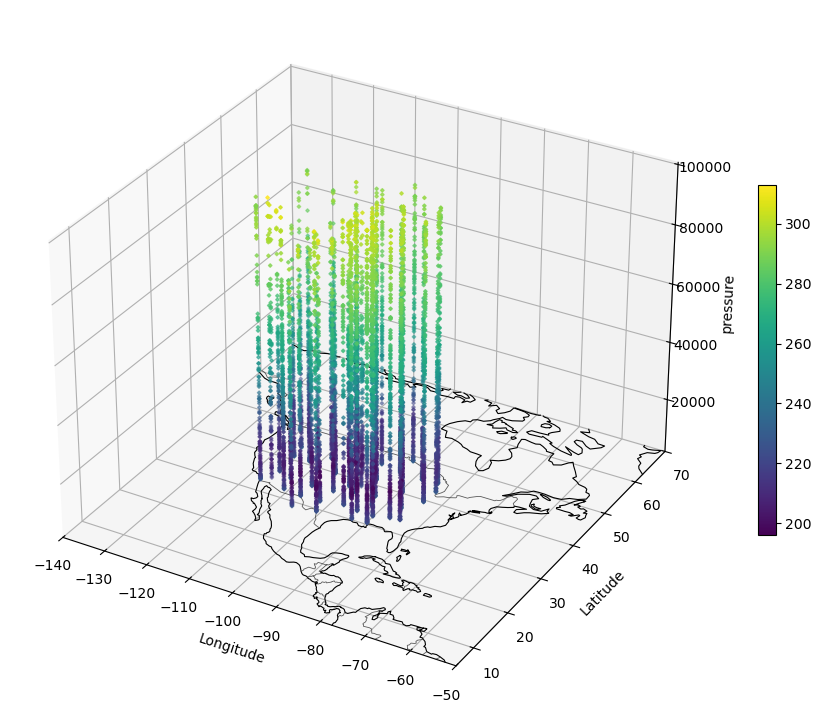

In [7]:
plot_obs_netcdf(fname, ObsTypeString, region, CopyString, QCString, maxQC, verbose=1, twoup=1)

<Figure size 1100x800 with 0 Axes>

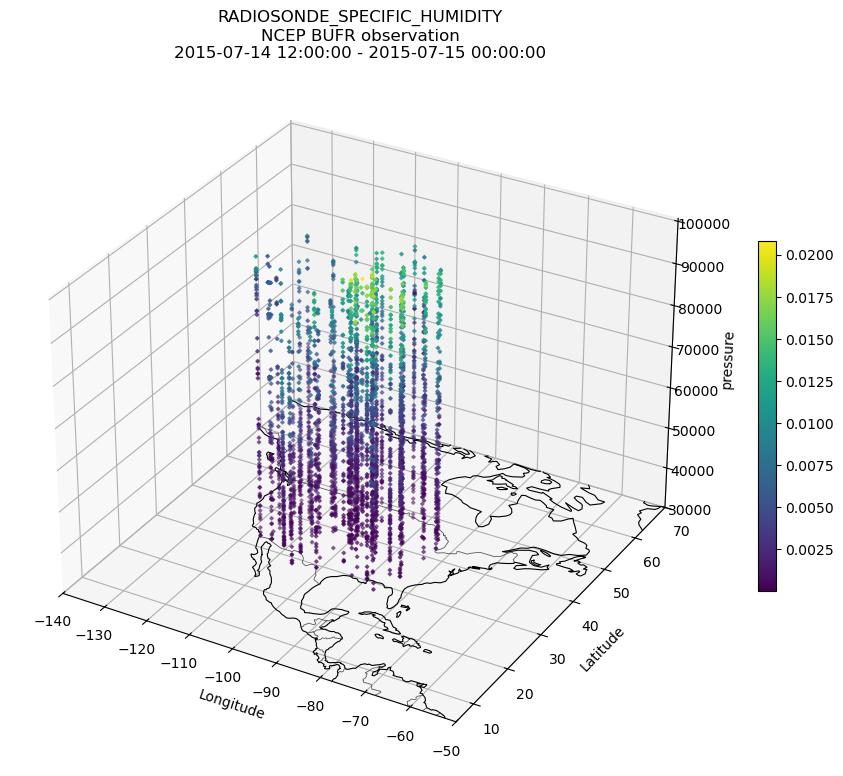

In [21]:
ObsTypeString = 'RADIOSONDE_SPECIFIC_HUMIDITY'
plot_obs_netcdf(fname, ObsTypeString, region, CopyString, QCString, maxQC, verbose=1, twoup=0)

<Figure size 800x1100 with 0 Axes>

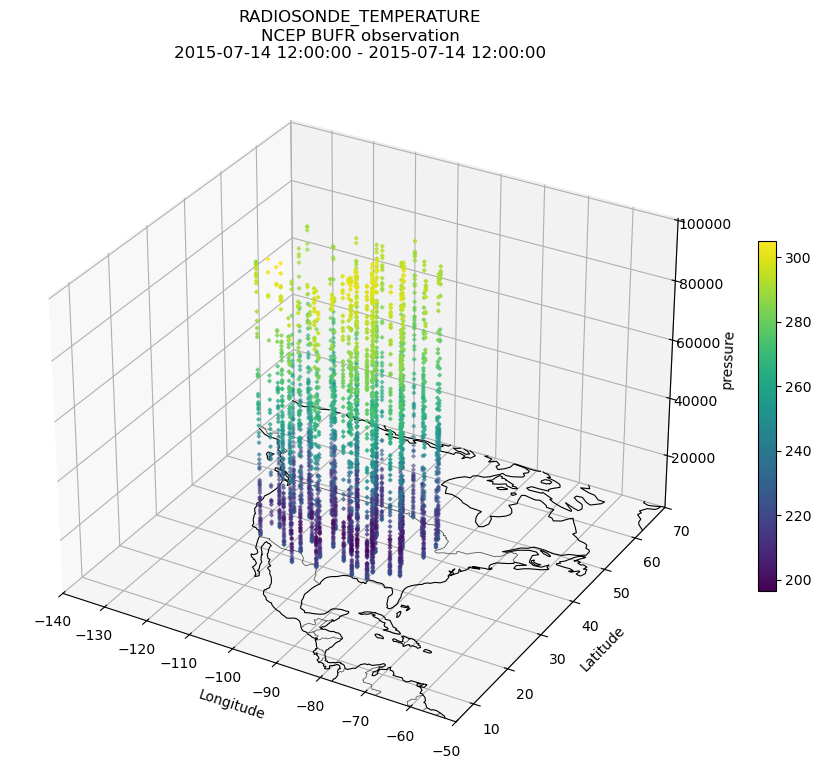

<Figure size 800x1100 with 0 Axes>

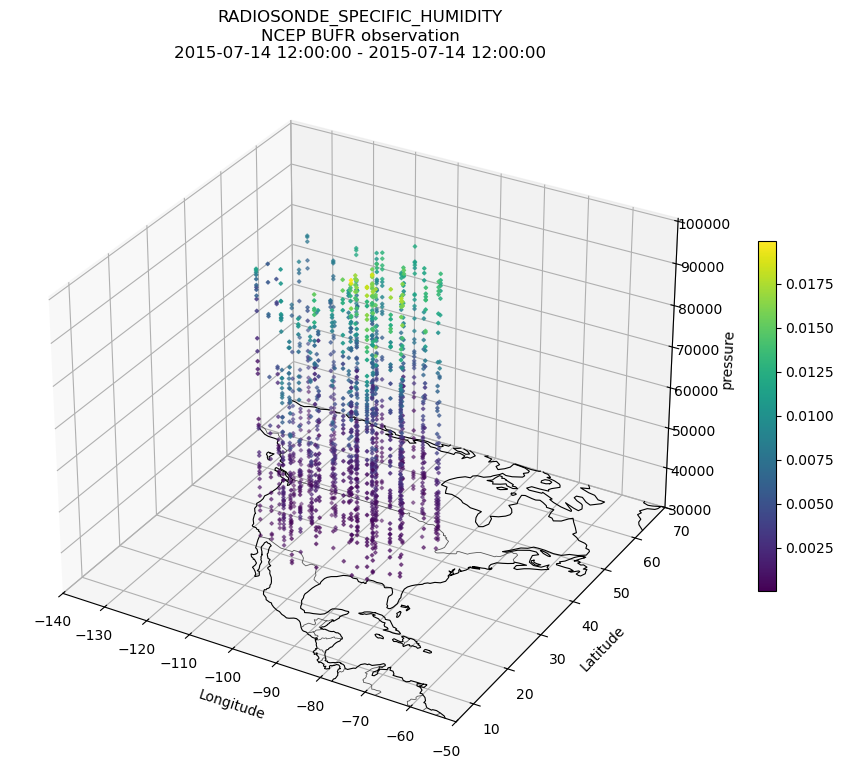

In [22]:
fname = '/gpfs/research/scratch/sa24m/tqprof/run2/osse_out/dart_cycle/output/2015071412/obs_epoch_001.nc'
ObsTypeString = 'RADIOSONDE_TEMPERATURE'
plot_obs_netcdf(fname, ObsTypeString, region, CopyString, QCString, maxQC, verbose=1, twoup=1)
ObsTypeString = 'RADIOSONDE_SPECIFIC_HUMIDITY'
plot_obs_netcdf(fname, ObsTypeString, region, CopyString, QCString, maxQC, verbose=1, twoup=1)

<Figure size 800x1100 with 0 Axes>

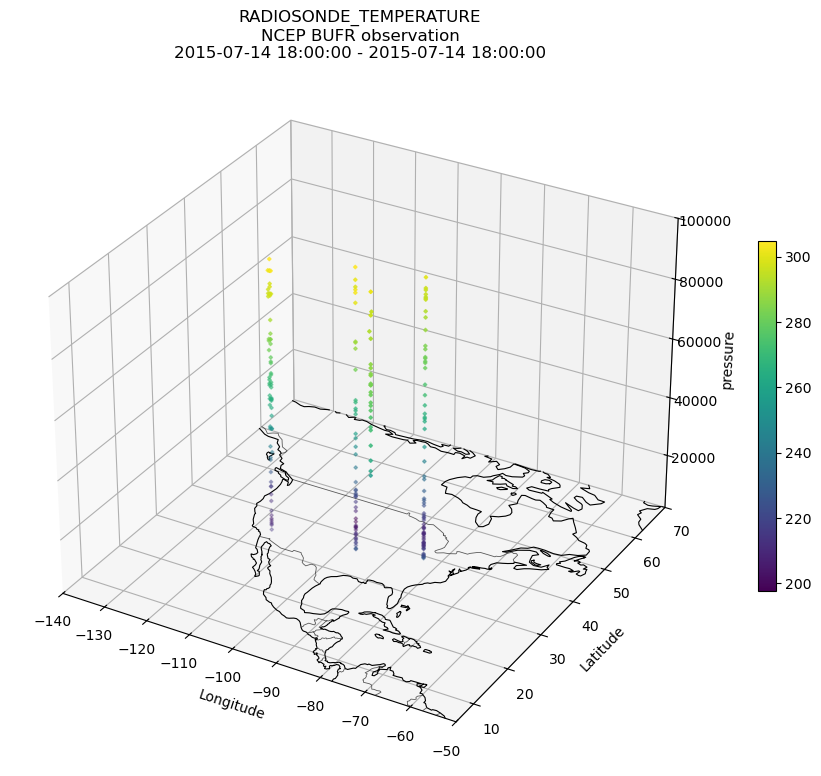

<Figure size 800x1100 with 0 Axes>

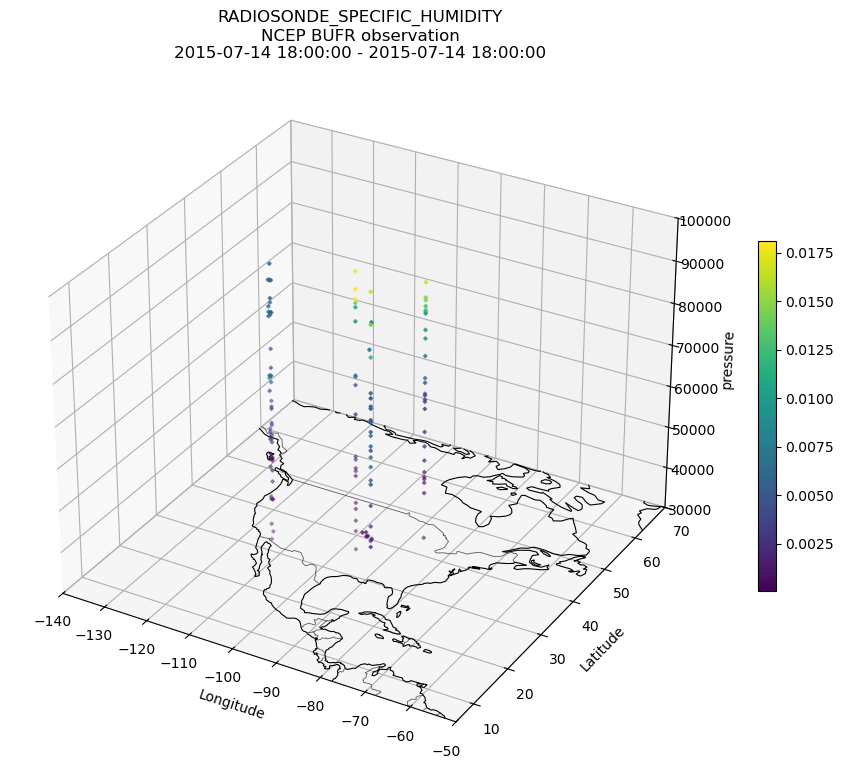

In [23]:
fname = '/gpfs/research/scratch/sa24m/tqprof/run2/osse_out/dart_cycle/output/2015071418/obs_epoch_001.nc'
ObsTypeString = 'RADIOSONDE_TEMPERATURE'
plot_obs_netcdf(fname, ObsTypeString, region, CopyString, QCString, maxQC, verbose=1, twoup=1)
ObsTypeString = 'RADIOSONDE_SPECIFIC_HUMIDITY'
plot_obs_netcdf(fname, ObsTypeString, region, CopyString, QCString, maxQC, verbose=1, twoup=1)

<Figure size 800x1100 with 0 Axes>

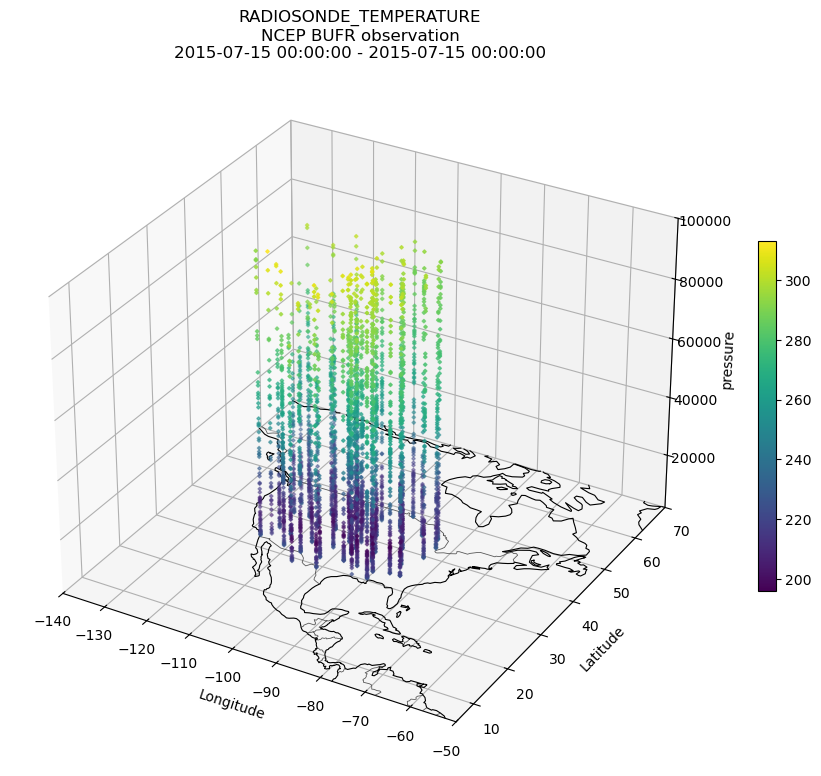

<Figure size 800x1100 with 0 Axes>

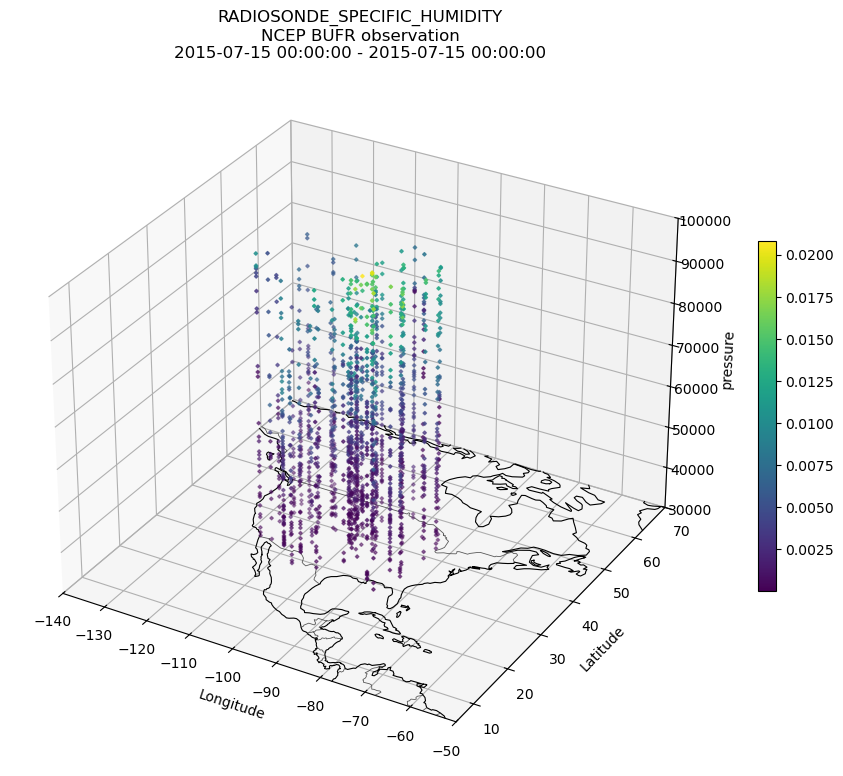

In [24]:
fname = '/gpfs/research/scratch/sa24m/tqprof/run2/osse_out/dart_cycle/output/2015071500/obs_epoch_001.nc'
ObsTypeString = 'RADIOSONDE_TEMPERATURE'
plot_obs_netcdf(fname, ObsTypeString, region, CopyString, QCString, maxQC, verbose=1, twoup=1)
ObsTypeString = 'RADIOSONDE_SPECIFIC_HUMIDITY'
plot_obs_netcdf(fname, ObsTypeString, region, CopyString, QCString, maxQC, verbose=1, twoup=1)

#### Model Space Diagostics

In [8]:

ds = read_obs_netcdf(
    fname, ObsTypeString, region, CopyString, QCString, verbose
)['obs']

In [13]:
def list_cycle_dirs(root: Path):
    return sorted(
        [p for p in root.iterdir() if p.is_dir() and re.fullmatch(r"\d{10}", p.name)],
        key=lambda p: p.name,
    )

def inc_path_for_cycle(cyc: Path, dom: str):
    return cyc / f"analysis_increment_{dom}.nc"

def post_path_for_cycle(cyc: Path, dom: str):
    return cyc / f"postassim_mean_{dom}.nc"

def ref_path_for_cycle(cyc: Path, dom: str):
    """Pick a reference geometry file from the cycle directory."""
    candidates = [
        cyc / f"preassim_mean_{dom}.nc",
        cyc / f"postassim_mean_{dom}.nc",
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"No reference file found. Tried: {', '.join([c.name for c in candidates])}")

def get_scalar_attr_or_var(nc: Dataset, name: str) -> float:
    """Scalar stored as global attr or scalar variable."""
    if name in nc.ncattrs():
        return float(nc.getncattr(name))
    if name in nc.variables:
        v = nc.variables[name][...]
        return float(np.asarray(v).item())
    raise KeyError(f"{name} not found as global attribute or variable")

def _as_2d(nc: Dataset, varname: str):
    v = nc.variables[varname]
    if v.ndim == 2:
        return v[:, :]
    if v.ndim == 3:
        return v[0, :, :]
    raise ValueError(f"{varname} expected 2D/3D, got ndim={v.ndim}, dims={v.dimensions}")

def setup_basemap_from_file(nc_path: Path):
    """Create Basemap + x/y arrays using projection metadata + XLAT/XLONG from a file."""
    with Dataset(str(nc_path), "r") as nc:
        x_dim = len(nc.dimensions["west_east"])
        y_dim = len(nc.dimensions["south_north"])

        dx = get_scalar_attr_or_var(nc, "DX")
        dy = get_scalar_attr_or_var(nc, "DY")
        width_meters  = dx * (x_dim - 1)
        height_meters = dy * (y_dim - 1)

        cen_lat  = get_scalar_attr_or_var(nc, "CEN_LAT")
        cen_lon  = get_scalar_attr_or_var(nc, "CEN_LON")
        truelat1 = get_scalar_attr_or_var(nc, "TRUELAT1")
        truelat2 = get_scalar_attr_or_var(nc, "TRUELAT2")

        m = Basemap(
            resolution="i",
            projection="lcc",
            width=width_meters,
            height=height_meters,
            lat_0=cen_lat, lon_0=cen_lon,
            lat_1=truelat1, lat_2=truelat2,
        )

        lons = _as_2d(nc, "XLONG")
        lats = _as_2d(nc, "XLAT")
        x, y = m(lons, lats)

    return x, y, m

def z_agl_mass_from_ref(ref_path: Path) -> np.ndarray:
    """Compute mass-level AGL height (m) from a reference file. Returns (z,y,x)."""
    with Dataset(str(ref_path), "r") as nc:
        zw = (nc.variables["PH"][0, ...] + nc.variables["PHB"][0, ...]) / 9.81  # stag levels
        z_msl = wrftools.unstagger_bt(zw)                                        # mass levels
        ter = _as_2d(nc, "HGT")
        z_agl = z_msl - ter                                                      # broadcast (z,y,x)
    return z_agl

def interp_inc_mass_to_zagl(inc_path: Path, z_agl_mass: np.ndarray, var_name: str, zagl_m: float) -> np.ndarray:
    """Interpolate a 3D increment field (mass grid) to constant AGL height. Returns 2D (y,x)."""
    with Dataset(str(inc_path), "r") as nc:
        var3d = nc.variables[var_name][0, ...]  # (z,y,x)
    out = wrftools.wrf_to_height(var3d, z_agl_mass, [float(zagl_m)])
    return out[0, :, :]

def interp_inc_uv_to_zagl(inc_path: Path, z_agl_mass: np.ndarray, zagl_m: float):
    """Interpolate U/V increments to constant AGL height. Returns U,V 2D on mass grid."""
    with Dataset(str(inc_path), "r") as nc:
        u = wrftools.unstagger_we(nc.variables["U"][0, ...])  # mass grid
        v = wrftools.unstagger_ns(nc.variables["V"][0, ...])  # mass grid
    u2 = wrftools.wrf_to_height(u, z_agl_mass, [float(zagl_m)])[0, :, :]
    v2 = wrftools.wrf_to_height(v, z_agl_mass, [float(zagl_m)])[0, :, :]
    return u2, v2


In [10]:
### Settings
# -------- User configuration --------
OUTPUT_ROOT = Path("/gpfs/home/sa24m/scratch/tqprof/run2/osse_out/dart_cycle/output")
DOMAIN = "d01"          # "d01" or "d02"
ZAGL_M = 1000.0         # target AGL height (m)

VAR_MASS = "QVAPOR"     # mass-grid 3D increment to plot (e.g., QVAPOR, T, QCLOUD, etc.)

PLOT_MAX_CYCLES = None  # set to an int (e.g., 6) to limit plots
QUIVER_SKIP = 12        # for wind vectors (bigger=less dense vectors)


In [11]:
cycle_dirs = list_cycle_dirs(OUTPUT_ROOT)
if PLOT_MAX_CYCLES is not None:
    cycle_dirs = cycle_dirs[:PLOT_MAX_CYCLES]

print(f"Found {len(cycle_dirs)} cycles.")
print("First few:", [d.name for d in cycle_dirs[:5]])


Found 3 cycles.
First few: ['2015071412', '2015071418', '2015071500']


## Plot 1: `VAR_MASS` increment at `ZAGL_M`

For each cycle:
1. pick `preassim_mean` if available, else `postassim_mean`
2. compute `z_agl(z,y,x)` from reference file
3. interpolate increment field to `ZAGL_M`

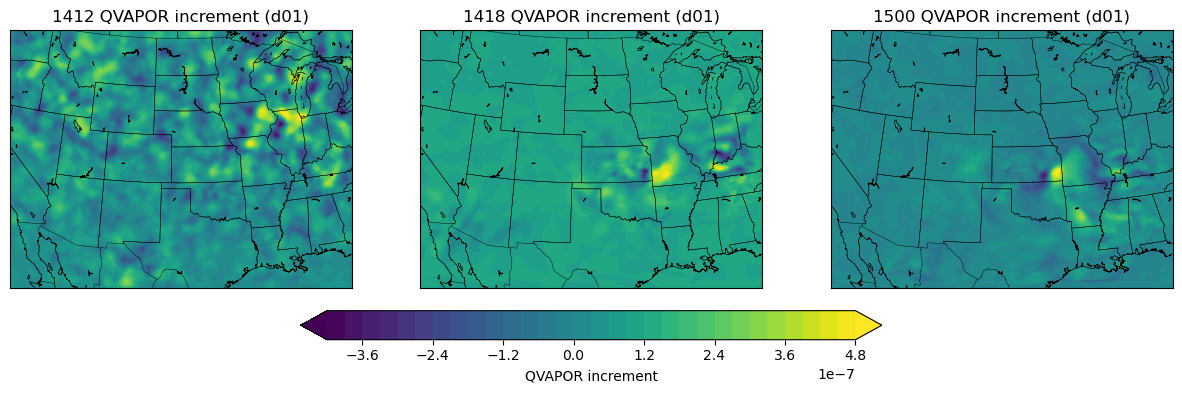

In [18]:
fig, ax = plt.subplots(nrows=1, ncols = 3, figsize=(15, 6))

for i, cyc in enumerate(cycle_dirs):
    inc_file = inc_path_for_cycle(cyc, DOMAIN)
    if not inc_file.exists():
        print(f"[{cyc.name}] Missing increment: {inc_file.name}")
        continue

    try:
        ref_file = ref_path_for_cycle(cyc, DOMAIN)
    except FileNotFoundError as e:
        print(f"[{cyc.name}] {e}")
        continue

    # Basemap from reference (guarantees lat/lon match its geometry)
    x, y, m = setup_basemap_from_file(ref_file)

    # Reference height grid
    z_agl = z_agl_mass_from_ref(ref_file)

    # Interpolate increment field to AGL
    fld2d = interp_inc_mass_to_zagl(inc_file, z_agl, VAR_MASS, ZAGL_M)

    if np.all(np.isnan(fld2d)):
        # helpful debug: check whether ZAGL_M is within the column range
        col = z_agl[:, z_agl.shape[1]//2, z_agl.shape[2]//2]
        print(f"[{cyc.name}] all-NaN after interpolation. Mid-column z range: {float(np.nanmin(col)):.1f}–{float(np.nanmax(col)):.1f} m")
        continue

    # fig, ax = plt.subplots(figsize=(8, 7))

    m.drawcoastlines(ax=ax[i], linewidth=0.5)
    m.drawstates(ax=ax[i], linewidth=0.3)
    m.drawcountries(ax=ax[i], linewidth=0.3)

    cs = m.contourf(x, y, fld2d, 31, extend="both", ax=ax[i])
    # cbar = plt.colorbar(cs, ax=ax[i], shrink=0.60, pad=0.02)
    # cbar.set_label(f"{VAR_MASS} increment")

    ax[i].set_title(f"{cyc.name[-4:]} {VAR_MASS} increment ({DOMAIN})")
# one shared colorbar at the bottom
cbar = fig.colorbar(
    cs,
    ax=ax.ravel().tolist(),
    orientation="horizontal",
    location="bottom",   # matplotlib >= 3.7; safe in most modern envs
    pad=0.05,            # space between plots and colorbar
    shrink=0.5,
)
cbar.set_label(f"{VAR_MASS} increment")

# plt.savefig(f"figures/{VAR_MASS} increment")


#### 1000m AGL analysis increment

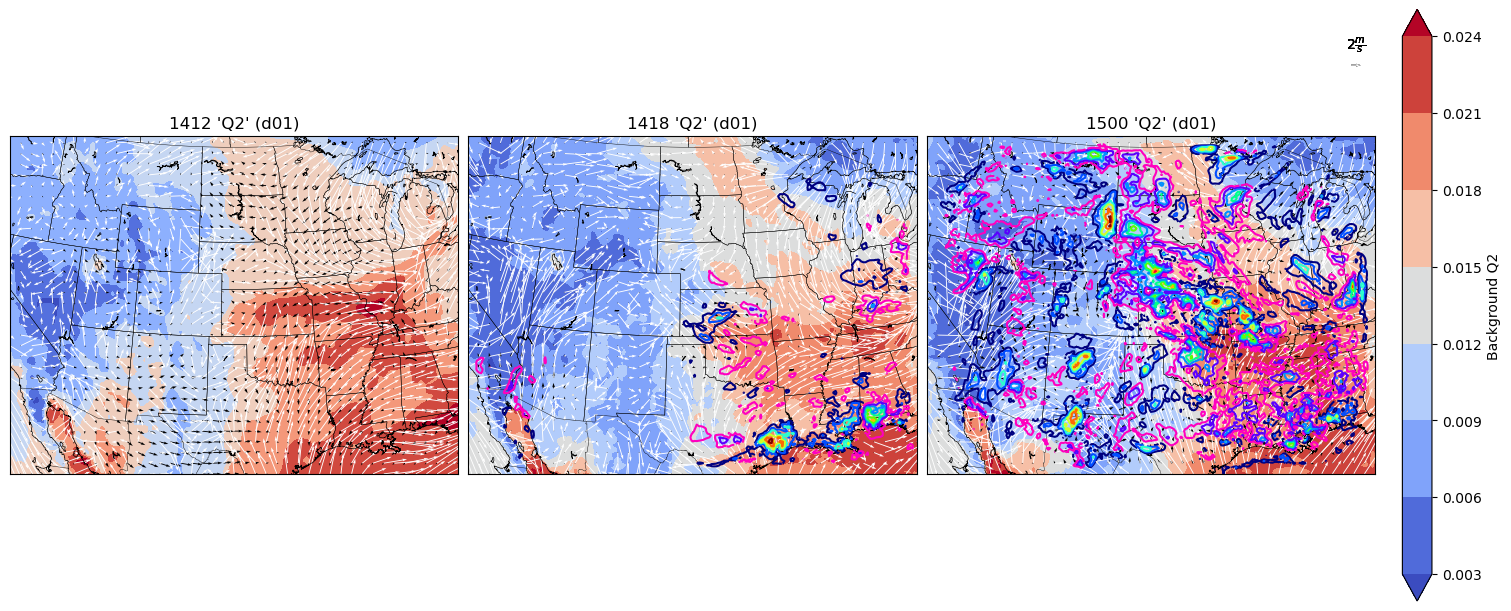

In [126]:
### Settings
# -------- User configuration --------
OUTPUT_ROOT = Path("/gpfs/home/sa24m/scratch/tqprof/run2/osse_out/dart_cycle/output")
DOMAIN = "d01"          # "d01" or "d02"
ZAGL_M = 1000.0         # target AGL height (m)
var="Q2"

fig, ax = plt.subplots(nrows=1, ncols = 3, figsize=(15, 6), constrained_layout=True)
for i, cyc in enumerate(cycle_dirs):
    ## Background plot of variable at selected altitude
    inc_file = inc_path_for_cycle(cyc, DOMAIN)
    post_file = post_path_for_cycle(cyc, DOMAIN)
    x, y, m = setup_basemap_from_file(ref_file)
    m.drawcoastlines(ax=ax[i], linewidth=0.5)
    m.drawstates(ax=ax[i], linewidth=0.3)
    m.drawcountries(ax=ax[i], linewidth=0.3)
    ds2d = xr.open_dataset(post_file)[var][0]
    cs = m.contourf(x, y, ds2d, extend="both", ax=ax[i], cmap='coolwarm',label=f"Background {var}")

    ### increments bakgroud field
    pos_inc = xr.open_dataset(inc_file)[var][0].where(lambda x: x > 0)
    m.contour(x, y, pos_inc, extend="both", ax=ax[i], cmap='jet', label=f"Positive Increments {var}")
    neg_inc = xr.open_dataset(inc_file)[var][0].where(lambda x: x < 0)
    m.contour(x, y, neg_inc, extend="both", ax=ax[i], cmap='gist_rainbow', label=f"Negative Increments {var}")

    ### wind increments
    z_agl = z_agl_mass_from_ref(post_file)
    u2d, v2d = interp_inc_uv_to_zagl(inc_file, z_agl, ZAGL_M)
    qf = 5
    Q = ax[i].quiver(
        x[::qf, ::qf], y[::qf, ::qf],
        u2d[::qf, ::qf], v2d[::qf, ::qf],
        color="k", scale=95, width=0.002, label=f"Wind Increments"
    )
    ax[i].quiverkey(Q, 0.9, 0.9, 2, r'$2 \frac{m}{s}$',
               coordinates='figure')
    ### Backgroud wind
    u2d_b = xr.open_dataset(post_file)['U'][0][0].values
    v2d_b = xr.open_dataset(post_file)['V'][0][0].values
    Q = ax[i].quiver(
        x[::qf, ::qf], y[::qf, ::qf],
        u2d_b[::qf, ::qf], v2d_b[::qf, ::qf],
        scale=95, width=0.002, color='white', label=f"Background Wind"
    )
    ax[i].quiverkey(Q, 0.9, 0.9, 2, r'$2 \frac{m}{s}$',
                   coordinates='figure')
    ax[i].set_title(f"{cyc.name[-4:]} 'Q2' ({DOMAIN})")

cbar = fig.colorbar(
    cs, ax=ax, orientation="vertical",
    fraction=0.035, pad=0.02
)
cbar.set_label(f"Background {var}", rotation=90)



In [188]:
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm
cmape = plt.cm.get_cmap('gist_rainbow')
cmaps = plt.cm.get_cmap('jet')
n_half = 128
colors = np.vstack((cmape(np.linspace(0, 1, n_half)), 
                    cmaps(np.linspace(0, 1, n_half))))
custom_cmap = LinearSegmentedColormap.from_list('neg_pos', colors)

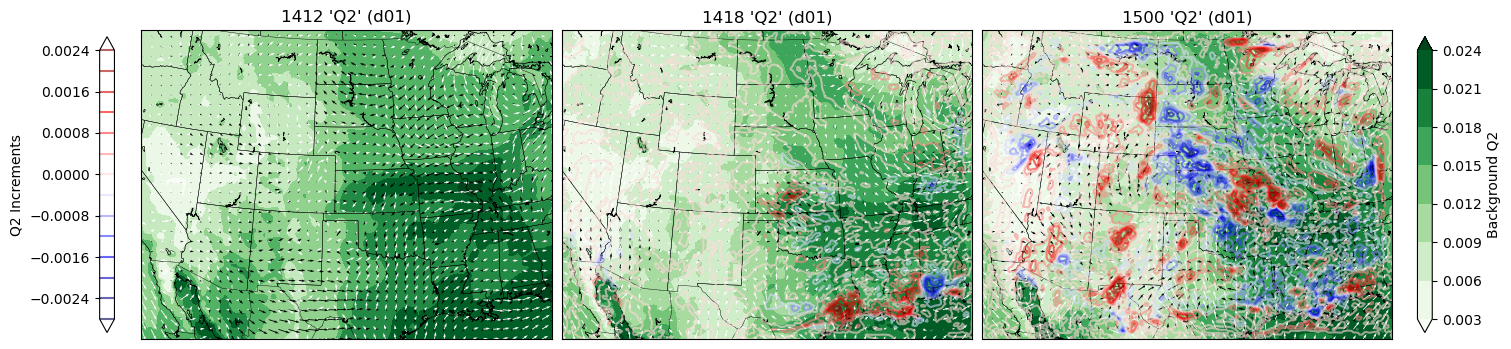

In [234]:
### Settings
# -------- User configuration --------
OUTPUT_ROOT = Path("/gpfs/home/sa24m/scratch/tqprof/run2/osse_out/dart_cycle/output")
DOMAIN = "d01"          # "d01" or "d02"
ZAGL_M = 1000.0         # target AGL height (m)
var = "Q2"
cmap1 = 'Greens'
cmap2 = 'seismic'
shrink = 0.5
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 6), constrained_layout=True)

for i, cyc in enumerate(cycle_dirs):
    ## Background plot of variable at selected altitude
    inc_file = inc_path_for_cycle(cyc, DOMAIN)
    post_file = post_path_for_cycle(cyc, DOMAIN)
    x, y, m = setup_basemap_from_file(ref_file)
    m.drawcoastlines(ax=ax[i], linewidth=0.5)
    m.drawstates(ax=ax[i], linewidth=0.3)
    m.drawcountries(ax=ax[i], linewidth=0.3)
    
    # Background field
    ds2d = xr.open_dataset(post_file)[var][0]
    cs_bg = m.contourf(x, y, ds2d, extend="both", ax=ax[i], cmap = cmap1,
                       label=f"Background {var}")
    
    # QC increments - read once and plot with divergent colormap
    qc_inc = xr.open_dataset(inc_file)[var][0].where(lambda x: abs(x) > 10^-6)
    cs_inc = m.contour(x, y, qc_inc, extend="both", ax=ax[i], cmap=cmap2, alpha=0.6, levels = 15)
    
    # pos_inc = xr.open_dataset(inc_file)[var][0].where(lambda x: x > 0)
    # m.contour(x, y, pos_inc, extend="both", ax=ax[i], cmap='jet', label=f"Positive Increments {var}")
    # neg_inc = xr.open_dataset(inc_file)[var][0].where(lambda x: x < 0)
    # m.contour(x, y, neg_inc, extend="both", ax=ax[i], cmap='gist_rainbow', label=f"Negative Increments {var}")
    
    # Wind increments
    z_agl = z_agl_mass_from_ref(post_file)
    u2d, v2d = interp_inc_uv_to_zagl(inc_file, z_agl, ZAGL_M)
    qf = 5
    Q_inc = ax[i].quiver(
        x[::qf, ::qf], y[::qf, ::qf],
        u2d[::qf, ::qf], v2d[::qf, ::qf],
        color="k", scale=80, width=0.002, label="Wind Increments"
    )
    
    # Background wind
    u2d_b = xr.open_dataset(post_file)['U'][0][0].values
    v2d_b = xr.open_dataset(post_file)['V'][0][0].values
    Q_bg = ax[i].quiver(
        x[::qf, ::qf], y[::qf, ::qf],
        u2d_b[::qf, ::qf], v2d_b[::qf, ::qf],
        scale=300, width=0.002, color='white', label="Background Wind"
    )
    
    ax[i].set_title(f"{cyc.name[-4:]} '{var}' ({DOMAIN})")

# Colorbar for background field (right side)
cbar_bg = fig.colorbar(
    cs_bg, ax=ax, orientation="vertical",
    fraction=0.035, pad=0.02, location='right', shrink=shrink
)
cbar_bg.set_label(f"Background {var}", rotation=90)

# Colorbar for increments (left side)
cbar_inc = fig.colorbar(
    cs_inc, ax=ax, orientation="vertical",
    fraction=0.035, pad=0.02, location='left', shrink=shrink
)
cbar_inc.set_label(f"{var} Increments", rotation=90)


In [237]:
ds = read_obs_netcdf(
        fname, ObsTypeString, region, CopyString, QCString, verbose
    )

In [239]:
xr.DataArray(ds)

<xarray.DataArray ()> Size: 8B
array({'numobs': 22130, 'lons': masked_array(data=[285.85, 285.85, 285.85, ..., 271.2 , 266.8 , 270.2 ],
             mask=False,
       fill_value=1e+20), 'lats': masked_array(data=[ 4.7,  4.7,  4.7, ..., 28.7, 32.2, 30. ],
             mask=False,
       fill_value=1e+20), 'Ztyp': masked_array(data=[2, 2, 2, ..., 2, 2, 2],
             mask=False,
       fill_value=999999,
            dtype=int32), 'z': masked_array(data=[75300., 70000., 59100., ..., 32540., 34530., 68080.],
             mask=False,
       fill_value=1e+20), 'keys': masked_array(data=[  7888,   7893,   7897, ..., 114685, 114688, 114691],
             mask=False,
       fill_value=999999,
            dtype=int32), 'obs': masked_array(data=[286.36, 282.16, 273.16, ..., 242.16, 249.16, 283.16],
             mask=[False, False, False, ..., False, False, False],
       fill_value=9.969209968386869e+36), 'time': array([datetime.datetime(2015, 7, 14, 12, 0),
       datetime.datetime(2015, 7, 14, 12, 0),
       datetime.datetime(2015, 7, 14, 12, 0), ...,
       datetime.datetime(2015, 7, 15, 0, 0),
       datetime.datetime(2015, 7, 15, 0, 0),
       datetime.datetime(2015, 7, 15, 0, 0)], dtype=object), 'qc': masked_array(data=[4, 4, 4, ..., 7, 0, 0],
             mask=False,
       fill_value=999999,
            dtype=int32), 'Zpositivedir': 'down', 'Zunits': 'pressure'},
      dtype=object)

## Plot 2: Wind increment vectors (U/V) at `ZAGL_M` (reference geometry)

Shaded: speed increment; vectors: U/V increments interpolated to AGL.


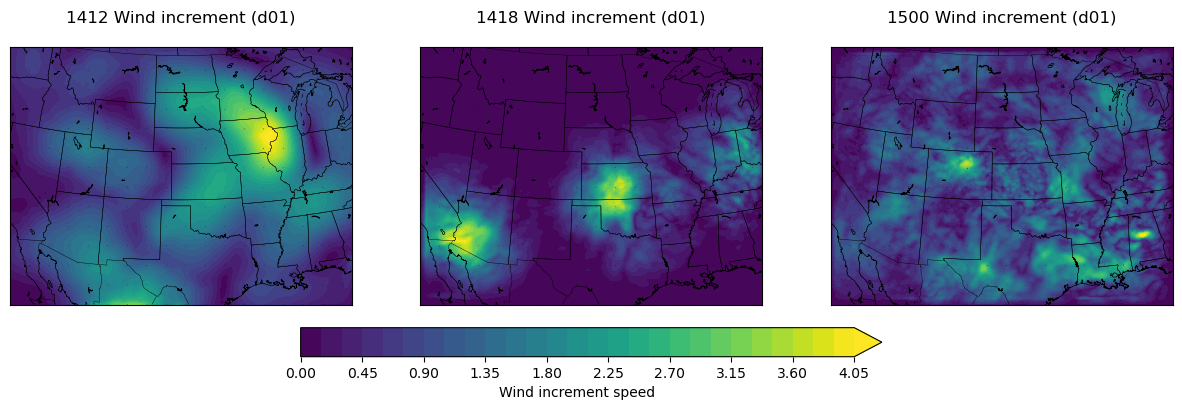

In [34]:
fig, ax = plt.subplots(nrows=1, ncols = 3, figsize=(15,6))
for i, cyc in enumerate(cycle_dirs):
    inc_file = inc_path_for_cycle(cyc, DOMAIN)

    x, y, m = setup_basemap_from_file(ref_file)
    z_agl = z_agl_mass_from_ref(ref_file)

    u2d, v2d = interp_inc_uv_to_zagl(inc_file, z_agl, ZAGL_M)
    spd = np.sqrt(u2d**2 + v2d**2)

    if np.all(np.isnan(spd)):
        print(f"[{cyc.name}] all-NaN wind after interpolation")
        continue

    # fig, ax = plt.subplots(figsize=(8, 7))
    m.drawcoastlines(ax=ax[i], linewidth=0.5)
    m.drawstates(ax=ax[i], linewidth=0.3)
    m.drawcountries(ax=ax[i], linewidth=0.3)

    cs = m.contourf(x, y, spd, 31, extend="max", ax=ax[i])
    # cbar = plt.colorbar(cs, ax=ax[i], shrink=0.85, pad=0.02)
    # cbar.set_label("Wind increment speed")

    ax[i].quiver(
        x[::QUIVER_SKIP, ::QUIVER_SKIP],
        y[::QUIVER_SKIP, ::QUIVER_SKIP],
        u2d[::QUIVER_SKIP, ::QUIVER_SKIP],
        v2d[::QUIVER_SKIP, ::QUIVER_SKIP],
        scale=700,
        width=0.002,
    )

    ax[i].set_title(f"{cyc.name[-4:]} Wind increment ({DOMAIN})\n")
cbar = fig.colorbar(
    cs,
    ax=ax.ravel().tolist(),
    orientation="horizontal",
    location="bottom",   # matplotlib >= 3.7; safe in most modern envs
    pad=0.05,            # space between plots and colorbar
    shrink=0.5,
)
cbar.set_label("Wind increment speed")

    # outpng = FIG_DIR / f"{cyc.name}_{DOMAIN}_UV_inc_{int(ZAGL_M)}mAGL_refgeo.png"
    # fig.savefig(outpng, bbox_inches="tight")
plt.savefig(f"figures/Wind increment speed")

    # plt.close(fig)

    # print(f"[{i:03d}] saved {outpng}")


In [35]:
# ---------- plot_dWRF-style diagnostics (BG/ANL differences) ----------

from scipy.ndimage import gaussian_filter

def bg_path_for_cycle(cyc: Path, dom: str) -> Path:
    p = cyc / f"preassim_mean_{dom}.nc"
    if not p.exists():
        raise FileNotFoundError(f"Missing BG file: {p}")
    return p

def anl_path_for_cycle(cyc: Path, dom: str) -> Path:
    p = cyc / f"postassim_mean_{dom}.nc"
    if not p.exists():
        raise FileNotFoundError(f"Missing ANL file: {p}")
    return p

def interp_VARmass_zlevs_agl_from_path(nc_path: Path, var_name: str, Zagl_interp: float) -> np.ndarray:
    """
    Matches plot_dWRF.py interp_VARmass_zlevs_agl() exactly, but takes a path.
    Returns 2D (y,x) at Zagl_interp AGL.
    """
    with Dataset(str(nc_path), "r") as nc:
        VAR = nc.variables[var_name][0, ...]  # (z,y,x)
        Z_stag = (nc.variables["PH"][0, ...] + nc.variables["PHB"][0, ...]) / 9.81
        Z = wrftools.unstagger_bt(Z_stag)
        ter = _as_2d(nc, "HGT")
        Z_agl = Z - ter
    zlevs = [float(Zagl_interp)]
    VAR_interp_all = wrftools.wrf_to_height(VAR, Z_agl, zlevs)
    return VAR_interp_all[0, :, :]

def interp_UV_zlevs_agl_from_path(nc_path: Path, Zagl_interp: float):
    """
    Matches plot_dWRF.py interp_UV_zlevs_agl() exactly, but takes a path.
    Returns U,V 2D (y,x) at Zagl_interp AGL on mass grid.
    """
    with Dataset(str(nc_path), "r") as nc:
        U = wrftools.unstagger_we(nc.variables["U"][0, ...])
        V = wrftools.unstagger_ns(nc.variables["V"][0, ...])
        Z_stag = (nc.variables["PH"][0, ...] + nc.variables["PHB"][0, ...]) / 9.81
        Z = wrftools.unstagger_bt(Z_stag)
        ter = _as_2d(nc, "HGT")
        Z_agl = Z - ter
    zlevs = [float(Zagl_interp)]
    U_interp = wrftools.wrf_to_height(U, Z_agl, zlevs)[0, :, :]
    V_interp = wrftools.wrf_to_height(V, Z_agl, zlevs)[0, :, :]
    return U_interp, V_interp

def get_W_zlevs_agl_from_path(nc_path: Path, zAGL: float = 1000.0) -> np.ndarray:
    """
    Matches plot_dWRF.py get_W_zlevs_agl() behavior, but takes a path.
    Returns W 2D (y,x) at zAGL AGL.
    """
    with Dataset(str(nc_path), "r") as nc:
        W_stag = nc.variables["W"][0, ...]   # (z_stag,y,x)
        W = wrftools.unstagger_bt(W_stag)    # (z,y,x)

        Z_stag = (nc.variables["PH"][0, ...] + nc.variables["PHB"][0, ...]) / 9.81
        Z = wrftools.unstagger_bt(Z_stag)
        ter = _as_2d(nc, "HGT")
        Z_agl = Z - ter

    zlevs = [float(zAGL)]
    W_int = wrftools.wrf_to_height(W, Z_agl, zlevs)
    return W_int[0, :, :]

def cref_from_path(nc_path: Path) -> np.ndarray:
    """CREF = max over z of REFL_10CM at time 0."""
    with Dataset(str(nc_path), "r") as nc:
        if "REFL_10CM" not in nc.variables:
            raise KeyError(f"REFL_10CM not found in {nc_path.name}")
        return np.nanmax(nc.variables["REFL_10CM"][0, ...], axis=0)

def wmax_from_path(nc_path: Path) -> np.ndarray:
    """Wmax = max over z of unstaggered W at time 0 (matches plot_dWmax)."""
    with Dataset(str(nc_path), "r") as nc:
        W_stag = nc.variables["W"][0, ...]
    W = wrftools.unstagger_bt(W_stag)
    return np.nanmax(W, axis=0)

def dxdy_from_path(nc_path: Path):
    with Dataset(str(nc_path), "r") as nc:
        dx = get_scalar_attr_or_var(nc, "DX")
        dy = get_scalar_attr_or_var(nc, "DY")
    return dx, dy

def calc_div_vec(U: np.ndarray, V: np.ndarray, dx: float, dy: float) -> np.ndarray:
    """
    Vectorized version of plot_dWRF.py calc_div(): same boundary NaN convention.
    U,V are 2D (y,x).
    """
    div = np.full_like(U, np.nan, dtype=float)
    div[1:-1, 1:-1] = ((U[1:-1, 2:] - U[1:-1, :-2]) / (2.0 * dx) +
                      (V[2:, 1:-1] - V[:-2, 1:-1]) / (2.0 * dy))
    return div

def compute_plot_dWRF_diagnostics_for_cycle(cyc: Path, dom: str, Zagl_interp: float, mv_name: str = "QVAPOR"):
    """
    Compute the same diagnostic fields used by plot_dWRF.py, but from:
      base = preassim_mean_{dom}.nc
      anl  = postassim_mean_{dom}.nc
    Returns a dict with arrays + basemap.
    """
    base_path = bg_path_for_cycle(cyc, dom)
    anl_path  = anl_path_for_cycle(cyc, dom)
    inc_path  = inc_path_for_cycle(cyc, dom)  # optional cross-check

    # Basemap/grid
    x, y, m = setup_basemap_from_file(base_path)
    dx, dy  = dxdy_from_path(base_path)

    # MV and dMV (g/kg like plot_dMV)
    MV_base = interp_VARmass_zlevs_agl_from_path(base_path, mv_name, Zagl_interp) * 1000.0
    MV_anl  = interp_VARmass_zlevs_agl_from_path(anl_path,  mv_name, Zagl_interp) * 1000.0
    dMV     = MV_anl - MV_base

    # Winds and increments
    U_base, V_base = interp_UV_zlevs_agl_from_path(base_path, Zagl_interp)
    U_anl,  V_anl  = interp_UV_zlevs_agl_from_path(anl_path,  Zagl_interp)
    dU, dV = U_anl - U_base, V_anl - V_base

    # W at 1000 m AGL (used for scatter masks in plot_dMV/dUV)
    W_1km = get_W_zlevs_agl_from_path(anl_path, 1000.0)

    # CREF (used as 30 dBZ contour)
    CREF_base = None
    CREF_anl  = None
    try:
        CREF_base = cref_from_path(base_path)
        CREF_anl  = cref_from_path(anl_path)
    except Exception:
        pass

    # Convergence diagnostic (plot_dCONV)
    div_base = calc_div_vec(U_base, V_base, dx, dy)
    div_anl  = calc_div_vec(U_anl,  V_anl,  dx, dy)
    conv_base = gaussian_filter(-1.0 * div_base * 10000.0, sigma=2)
    conv_anl  = gaussian_filter(-1.0 * div_anl  * 10000.0, sigma=2)
    dCONV = conv_anl - conv_base

    # W at Zagl_interp and dW (plot_dW)
    Wz_base = get_W_zlevs_agl_from_path(base_path, Zagl_interp)
    Wz_anl  = get_W_zlevs_agl_from_path(anl_path,  Zagl_interp)
    dWz     = Wz_anl - Wz_base

    # Wmax and dWmax (plot_dWmax)
    Wmax_base = wmax_from_path(base_path)
    Wmax_anl  = wmax_from_path(anl_path)
    dWmax     = Wmax_anl - Wmax_base

    # Optional cross-check: increment file should be similar to (anl-base)
    inc_checks = {}
    if inc_path.exists():
        try:
            z_agl = z_agl_mass_from_ref(base_path)
            inc_mv = interp_inc_mass_to_zagl(inc_path, z_agl, mv_name, Zagl_interp) * 1000.0
            inc_checks["dMV_incfile_minus_anlbase_rms"] = float(np.sqrt(np.nanmean((inc_mv - dMV)**2)))
        except Exception:
            pass
        try:
            z_agl = z_agl_mass_from_ref(base_path)
            u_inc, v_inc = interp_inc_uv_to_zagl(inc_path, z_agl, Zagl_interp)
            inc_checks["dU_incfile_minus_anlbase_rms"] = float(np.sqrt(np.nanmean((u_inc - dU)**2)))
            inc_checks["dV_incfile_minus_anlbase_rms"] = float(np.sqrt(np.nanmean((v_inc - dV)**2)))
        except Exception:
            pass

    return dict(
        cyc=cyc, base=base_path, anl=anl_path, inc=inc_path,
        x=x, y=y, m=m, dx=dx, dy=dy,
        MV_base=MV_base, MV_anl=MV_anl, dMV=dMV,
        U_base=U_base, V_base=V_base, U_anl=U_anl, V_anl=V_anl, dU=dU, dV=dV,
        W_1km=W_1km,
        CREF_base=CREF_base, CREF=CREF_anl,
        dCONV=dCONV,
        Wz_base=Wz_base, Wz_anl=Wz_anl, dWz=dWz,
        dWmax=dWmax,
        inc_checks=inc_checks
    )


2015071412 {'dMV_incfile_minus_anlbase_rms': 2.196045285057118e-05, 'dU_incfile_minus_anlbase_rms': 0.08742402753665607, 'dV_incfile_minus_anlbase_rms': 0.059801418216388444}
2015071418 {'dMV_incfile_minus_anlbase_rms': 1.0149321224567584e-05, 'dU_incfile_minus_anlbase_rms': 0.029418454589146666, 'dV_incfile_minus_anlbase_rms': 0.03349916914859065}
2015071500 {'dMV_incfile_minus_anlbase_rms': 2.2941052517599105e-05, 'dU_incfile_minus_anlbase_rms': 0.1377974904183615, 'dV_incfile_minus_anlbase_rms': 0.07852464158222683}


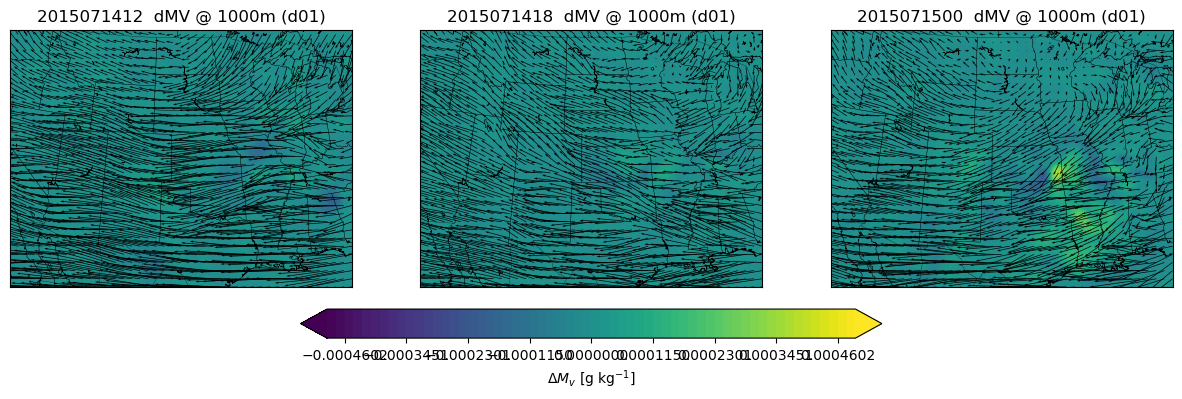

In [37]:
# Compute once
diags = []
for cyc in cycle_dirs:
    try:
        D = compute_plot_dWRF_diagnostics_for_cycle(cyc, DOMAIN, ZAGL_M, mv_name="QVAPOR")
        diags.append(D)
        if D["inc_checks"]:
            print(cyc.name, D["inc_checks"])
    except Exception as e:
        print(f"[{cyc.name}] skip: {e}")

if not diags:
    raise RuntimeError("No cycles produced diagnostics.")

# Levels like plot_dMV (g/kg), symmetric around 0
vmax = float(np.nanmax([np.nanmax(np.abs(D["dMV"])) for D in diags]))
levels = np.linspace(-vmax, vmax, 61)

n = len(diags)
ncols = 3
nrows = math.ceil(n / ncols)
fig, ax = plt.subplots(nrows, ncols, figsize=(5*ncols, 4.8*nrows), squeeze=False)
axs = ax.ravel()

mappable = None
for i, D in enumerate(diags):
    m = D["m"]; x = D["x"]; y = D["y"]
    ax_i = axs[i]

    m.drawcoastlines(ax=ax_i, linewidth=0.4)
    m.drawstates(ax=ax_i, linewidth=0.2)
    m.drawcountries(ax=ax_i, linewidth=0.2)

    dmv_s = gaussian_filter(D["dMV"], 2.0)  # plot_dMV smoothing
    mappable = m.contourf(x, y, dmv_s, levels=levels, extend="both", ax=ax_i)

    # CREF 30 dBZ contour if available
    if D["CREF"] is not None:
        m.contour(x, y, D["CREF"], levels=[30.0], colors="k", linewidths=1.2, ax=ax_i)

    # W mask (analysis W at 1 km)
    W_field = gaussian_filter(D["W_1km"], 2.0)
    mask = W_field > 0.15
    if np.any(mask):
        ax_i.scatter(x[mask], y[mask], s=0.2)

    # Full wind vectors (analysis), like plot_dMV
    qf = 5
    ax_i.quiver(
        x[::qf, ::qf], y[::qf, ::qf],
        D["U_anl"][::qf, ::qf], D["V_anl"][::qf, ::qf],
        color="k", scale=95, width=0.002
    )

    ax_i.set_title(f"{D['cyc'].name}  dMV @ {int(ZAGL_M)}m ({DOMAIN})")
# remove unused axes (robust)
for j in range(n, len(axs)):
    fig.delaxes(axs[j])

# shared colorbar attached only to used subplot axes
cbar = fig.colorbar(
    mappable,
    ax=axs[:n].tolist(),
    orientation="horizontal",
    pad=0.06,
    shrink=0.5,
)
cbar.set_label(r"$\Delta M_v$ [g kg$^{-1}$]")

plt.show()

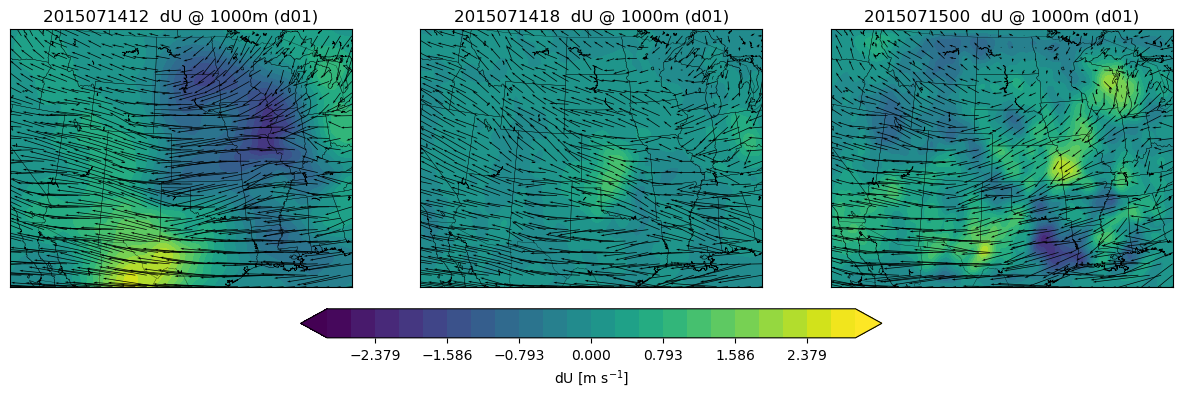

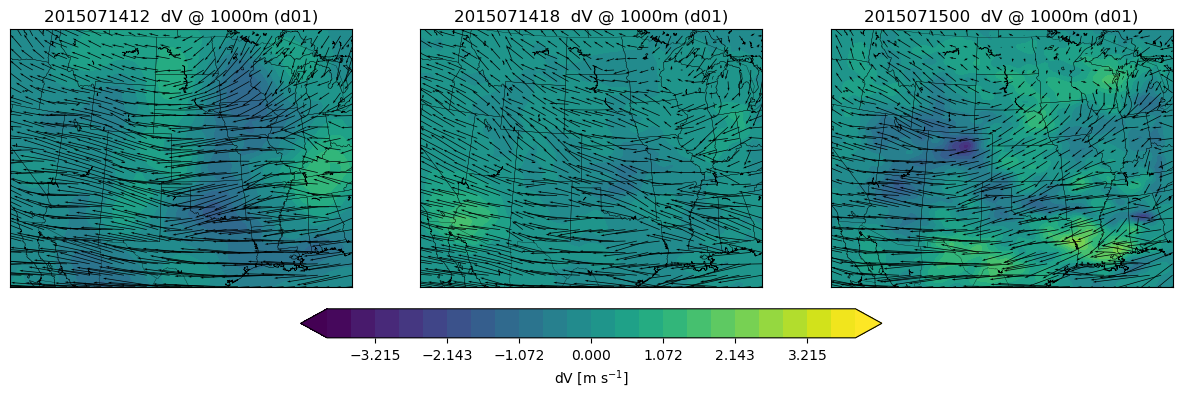

In [44]:
def plot_dUV_panels(diags, component="dU"):
    import math
    vmax = float(np.nanmax([np.nanmax(np.abs(D[component])) for D in diags]))
    levels = np.linspace(-vmax, vmax, 23)

    n = len(diags)
    ncols = 3
    nrows = math.ceil(n / ncols)
    fig, ax = plt.subplots(nrows, ncols, figsize=(5*ncols, 4.8*nrows), squeeze=False)
    axs = ax.ravel()

    mappable = None
    for i, D in enumerate(diags):
        m = D["m"]; x = D["x"]; y = D["y"]
        ax_i = axs[i]
        m.drawcoastlines(ax=ax_i, linewidth=0.4)
        m.drawstates(ax=ax_i, linewidth=0.2)
        m.drawcountries(ax=ax_i, linewidth=0.2)

        field = gaussian_filter(D[component], 2.0)
        mappable = m.contourf(x, y, field, levels=levels, extend="both", ax=ax_i)

        if D["CREF"] is not None:
            m.contour(x, y, D["CREF"], levels=[30.0], colors="dimgray", linewidths=1.0, ax=ax_i)

        W_field = gaussian_filter(D["W_1km"], 2.0)
        mask = W_field > 0.15
        if np.any(mask):
            ax_i.scatter(x[mask], y[mask], s=0.2)

        qf = 7
        ax_i.quiver(
            x[::qf, ::qf], y[::qf, ::qf],
            D["U_anl"][::qf, ::qf], D["V_anl"][::qf, ::qf],
            color="k", scale=95, width=0.002
        )

        ax_i.set_title(f"{D['cyc'].name}  {component} @ {int(ZAGL_M)}m ({DOMAIN})")

    for j in range(i+1, len(axs)):
        fig.delaxes(axs[j])

    cbar = fig.colorbar(mappable, ax=fig.axes, orientation="horizontal", pad=0.06, shrink=0.5)
    cbar.set_label(f"{component} [m s$^{{-1}}$]")
    plt.savefig(f"{component}.png")

plot_dUV_panels(diags, "dU")
plot_dUV_panels(diags, "dV")


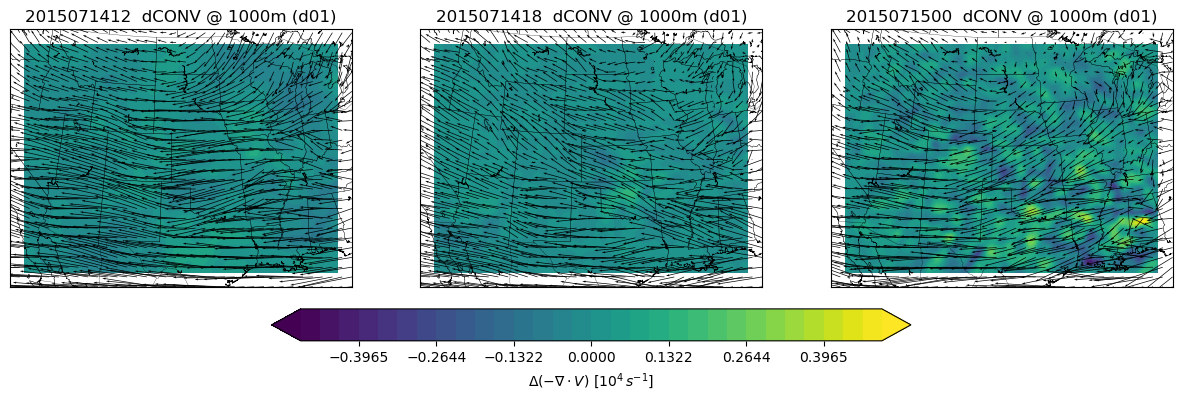

In [46]:
vmax = float(np.nanmax([np.nanmax(np.abs(D["dCONV"])) for D in diags]))
levels = np.linspace(-vmax, vmax, 31)

n = len(diags)
ncols = 3
nrows = math.ceil(n / ncols)
fig, ax = plt.subplots(nrows, ncols, figsize=(5*ncols, 4.8*nrows), squeeze=False)
axs = ax.ravel()

mappable = None
for i, D in enumerate(diags):
    m = D["m"]; x = D["x"]; y = D["y"]
    ax_i = axs[i]
    m.drawcoastlines(ax=ax_i, linewidth=0.4)
    m.drawstates(ax=ax_i, linewidth=0.2)
    m.drawcountries(ax=ax_i, linewidth=0.2)

    mappable = m.contourf(x, y, D["dCONV"], levels=levels, extend="both", ax=ax_i)

    if D["CREF"] is not None:
        m.contour(x, y, D["CREF"], levels=[30.0], colors="k", linewidths=1.0, ax=ax_i)

    qf = 6
    ax_i.quiver(
        x[::qf, ::qf], y[::qf, ::qf],
        D["U_anl"][::qf, ::qf], D["V_anl"][::qf, ::qf],
        color="k", scale=95, width=0.002
    )
    ax_i.set_title(f"{D['cyc'].name}  dCONV @ {int(ZAGL_M)}m ({DOMAIN})")

for j in range(i+1, len(axs)):
    fig.delaxes(axs[j])

cbar = fig.colorbar(mappable, ax=fig.axes, orientation="horizontal", pad=0.06, shrink=0.55)
cbar.set_label(r"$\Delta(-\nabla\cdot V)$ [$10^4\,s^{-1}$]")
plt.savefig(r"figures/$\Delta(-\nabla\cdot V)$")

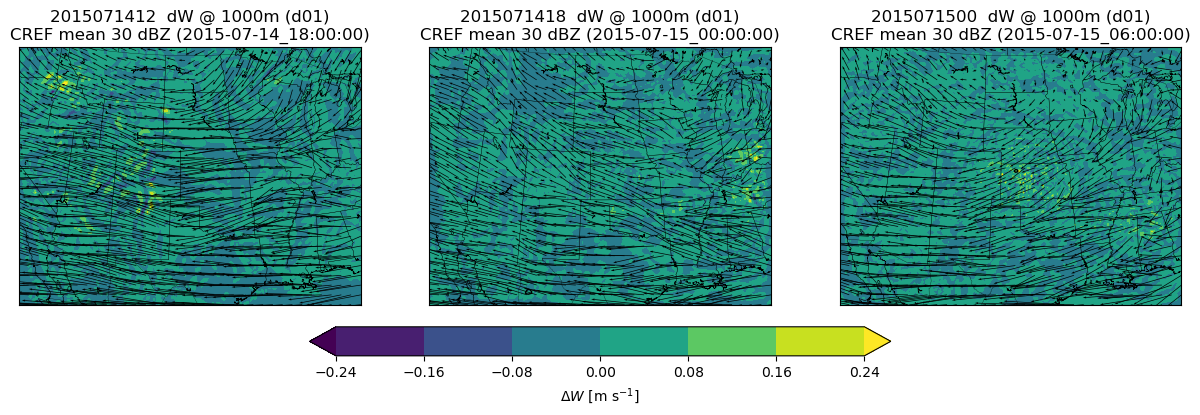

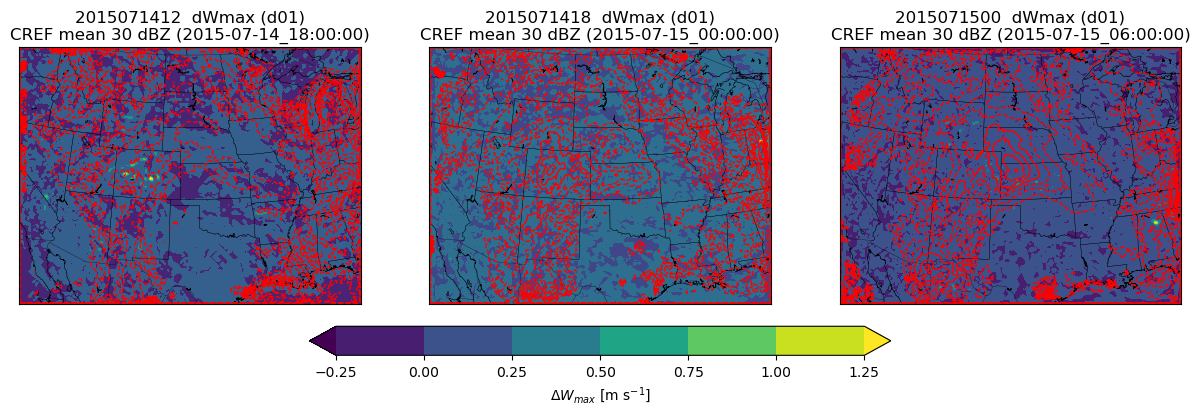

In [48]:

from datetime import datetime, timedelta

CYCLE_HOURS = 6  # <-- set to your cycling interval (e.g., 6)

def cycle_to_wrf_time(cyc_name_YYYYMMDDHH: str, fhours: int = CYCLE_HOURS) -> str:
    """
    Convert a cycle directory name like '2015071412' into a wrfout valid time string
    like '2015-07-14_18:00:00' using a +fhours forecast lead.
    """
    t0 = datetime.strptime(cyc_name_YYYYMMDDHH, "%Y%m%d%H")
    t1 = t0 + timedelta(hours=fhours)
    return t1.strftime("%Y-%m-%d_%H:%M:%S")

import glob
import numpy as np
from pathlib import Path
from netCDF4 import Dataset

def find_member_wrfout_paths(cyc: Path, dom: str, wrf_time: str,
                             mem_glob="e0??",
                             subdir="WRFIN"):
    """
    Example expected:
      <cyc>/WRFIN/e001/wrfout_d02_2015-07-14_18:00:00
    """
    fname = f"wrfout_{dom}_{wrf_time}"
    pattern = str(cyc / subdir / mem_glob / fname)
    paths = sorted(Path(p) for p in glob.glob(pattern))
    if not paths:
        raise FileNotFoundError(f"No member wrfout found with pattern: {pattern}")
    return paths

def cref_from_wrfout(path: Path) -> np.ndarray:
    """Composite reflectivity: max over z of REFL_10CM."""
    with Dataset(str(path), "r") as nc:
        if "REFL_10CM" not in nc.variables:
            raise KeyError(f"REFL_10CM missing in {path}")
        refl = nc.variables["REFL_10CM"][0, ...]  # (z,y,x)
    return np.nanmax(refl, axis=0)  # (y,x)

def ensemble_cref_stats(member_paths):
    """
    Returns:
      cref_mean (y,x),
      cref_prob30 (y,x) in percent,
      cref_max (y,x)
    """
    stack = [cref_from_wrfout(p) for p in member_paths]
    A = np.stack(stack, axis=0)  # (nmem,y,x)
    cref_mean = np.nanmean(A, axis=0)
    cref_max  = np.nanmax(A, axis=0)
    cref_prob30 = 100.0 * np.nanmean(A >= 30.0, axis=0)
    return cref_mean, cref_prob30, cref_max


# ----------------------------
# 1) Attach ensemble CREF once
# ----------------------------
CYCLE_HOURS = 6  # <-- set correctly

for D in diags:
    try:
        wrf_time = cycle_to_wrf_time(D["cyc"].name, fhours=CYCLE_HOURS)
        member_paths = find_member_wrfout_paths(D["cyc"], DOMAIN, wrf_time)
        cref_mean, cref_prob30, cref_max = ensemble_cref_stats(member_paths)

        D["CREF_ens_mean"] = cref_mean
        D["CREF_ens_prob30"] = cref_prob30
        D["wrf_time"] = wrf_time
    except Exception as e:
        print(f"[{D['cyc'].name}] CREF overlay skipped: {e}")
        D["CREF_ens_mean"] = None
        D["CREF_ens_prob30"] = None
        D["wrf_time"] = None


# ----------------------------
# 2) dW at ZAGL_M
# ----------------------------
import math

vmax = float(np.nanmax([np.nanmax(np.abs(D["dWz"])) for D in diags]))
levels = np.linspace(-vmax, vmax, 31)

n = len(diags)
ncols = 3
nrows = math.ceil(n / ncols)

fig, ax = plt.subplots(nrows, ncols, figsize=(5*ncols, 4.8*nrows), squeeze=False)
axs = ax.ravel()

mappable = None
for i, D in enumerate(diags):
    m = D["m"]; x = D["x"]; y = D["y"]
    ax_i = axs[i]

    m.drawcoastlines(ax=ax_i, linewidth=0.4)
    m.drawstates(ax=ax_i, linewidth=0.2)
    m.drawcountries(ax=ax_i, linewidth=0.2)

    # Filled increment
    mappable = m.contourf(x, y, D["dWz"], extend="both", ax=ax_i)

    # Overlay ensemble mean CREF 30 dBZ contour (if available)
    if D.get("CREF_ens_mean") is not None:
        m.contour(x, y, D["CREF_ens_mean"], levels=[30.0], colors="k", linewidths=1.0, ax=ax_i)

    # Wind vectors
    qf = 6
    ax_i.quiver(
        x[::qf, ::qf], y[::qf, ::qf],
        D["U_anl"][::qf, ::qf], D["V_anl"][::qf, ::qf],
        color="k", scale=95, width=0.002
    )

    # Title
    extra = f"\nCREF mean 30 dBZ ({D['wrf_time']})" if D.get("wrf_time") else ""
    ax_i.set_title(f"{D['cyc'].name}  dW @ {int(ZAGL_M)}m ({DOMAIN}){extra}")

# delete unused axes
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

# one shared colorbar
cbar = fig.colorbar(mappable, ax=axs[:n].tolist(), orientation="horizontal", pad=0.06, shrink=0.5)
cbar.set_label(r"$\Delta W$ [m s$^{-1}$]")
plt.savefig(r"$\Delta W$ [m s$^{-1}$]")


# ----------------------------
# 3) dWmax
# ----------------------------
vmax = float(np.nanmax([np.nanmax(np.abs(D["dWmax"])) for D in diags]))
levels = np.linspace(-vmax, vmax, 31)

fig, ax = plt.subplots(nrows, ncols, figsize=(5*ncols, 4.8*nrows), squeeze=False)
axs = ax.ravel()

mappable = None
for i, D in enumerate(diags):
    m = D["m"]; x = D["x"]; y = D["y"]
    ax_i = axs[i]

    m.drawcoastlines(ax=ax_i, linewidth=0.4)
    m.drawstates(ax=ax_i, linewidth=0.2)
    m.drawcountries(ax=ax_i, linewidth=0.2)

    # Filled increment
    mappable = m.contourf(x, y, D["dWmax"], extend="both", ax=ax_i)

    # Overlay ensemble mean CREF 30 dBZ contour (if available)
    if D.get("CREF_ens_mean") is not None:
        m.contour(x, y, D["CREF_ens_mean"], colors="r", linewidths=1.0, ax=ax_i)

    extra = f"\nCREF mean 30 dBZ ({D['wrf_time']})" if D.get("wrf_time") else ""
    ax_i.set_title(f"{D['cyc'].name}  dWmax ({DOMAIN}){extra}")

# delete unused axes
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

# one shared colorbar
cbar = fig.colorbar(mappable, ax=axs[:n].tolist(), orientation="horizontal", pad=0.06, shrink=0.5)
cbar.set_label(r"$\Delta W_{max}$ [m s$^{-1}$]")
plt.savefig(r"figures/$\Delta W_{max}$ [m s$^{-1}$]")


In [ ]:
def plot_obs_netcdf(fname, ObsTypeString, region, CopyString,
                    QCString, maxQC, verbose=1, twoup=1):
    if twoup > 0:
        fig = plt.figure(figsize=(8, 11))
        positions = [
            [0.1, 0.55, 0.8, 0.35],
            [0.1, 0.10, 0.8, 0.35],
            [0.1, 0.02, 0.8, 0.08],
        ]
    else:
        fig = plt.figure(figsize=(11, 8))
        positions = [
            [0.1, 0.20, 0.8, 0.65],
            [0.1, 0.20, 0.8, 0.65],
            [0.1, 0.05, 0.8, 0.10],
        ]
    data = read_obs_netcdf(
        fname, ObsTypeString, region, CopyString, QCString, verbose
    )
    # ------------------------------------------------------------------
    # QC filtering
    # ------------------------------------------------------------------
    flaggedobs = {}
    if data["qc"].size > 0 and maxQC is not None:

        bad = np.where(data["qc"] > maxQC)[0]
        good = np.where(data["qc"] <= maxQC)[0]

        data["numflagged"] = len(bad)
        data["numgood"] = len(good)

        if len(bad) > 0:
            for k in ["lons", "lats", "Ztyp", "z", "obs", "qc"]:
                flaggedobs[k] = data[k][bad]

        for k in ["lons", "lats", "Ztyp", "z", "obs", "qc"]:
            data[k] = data[k][good]

        # ------------------------------------------------------------------
        # Remove NaNs
        # ------------------------------------------------------------------

        finite = np.isfinite(data["obs"])
        nanobs = {"numflagged": np.sum(~finite)}
         
        if nanobs["numflagged"] > 0:
            nanobs["string"] = f"{nanobs['numflagged']} obs have unplottable values."
            for k in ["lons", "lats", "Ztyp", "z", "qc"]:
                nanobs[k] = obsstruct[k][~finite]

            for k in ["lons", "lats", "Ztyp", "z", "obs", "qc"]:
                obsstruct[k] = obsstruct[k][finite]
        else:
            nanobs["string"] = 'No "good" observations with NaN values.'

    # ------------------------------------------------
    # Main plot
    # ------------------------------------------------
    lons = lon_to_180(data["lons"])
    lats = np.asarray(data["lats"], dtype=float)
    zs   = np.asarray(data["z"], dtype=float)
    obs  = np.asarray(data["obs"], dtype=float)

    # Convert region lon bounds to [-180,180)
    xmin = float(lon_to_180(region[0]))+20 # West
    xmax = float(lon_to_180(region[1]))-20 # East
    ymin = float(region[2])+5 # South
    ymax = float(region[3])-20 # North


    zmin = float(zs.min()) if zs.size else 0.0
    zmax = float(zs.max()) if zs.size else 1.0

    extent = (xmin, xmax, ymin, ymax)

    fig = plt.figure(figsize=(20, 20))
    positions = [
        [0.1, 0.55, 0.8, 0.35],
        [0.1, 0.10, 0.8, 0.35],
        [0.1, 0.02, 0.8, 0.08],
    ]
    ax = fig.add_axes(positions[0], projection="3d")

    # 3D scatter
    sc = ax.scatter(lons, lats, zs, s=3, c=obs, cmap="viridis", marker="D")

    # Limits / labels
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_zlim(zmin, zmax)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_zlabel(zlabel_from_Ztyp(data["Ztyp"][0]))

    add_feature_floor_clipped(
        ax, cfeature.COASTLINE.with_scale("110m"), zmin, extent,
        facecolor=None, edgecolor="k", lw=0.8, alpha=1.0
    )
    add_feature_floor_clipped(
        ax, cfeature.BORDERS.with_scale("110m"), zmin, extent,
        facecolor=None, edgecolor="0.2", lw=0.6, alpha=0.8
    )
    add_feature_floor_clipped(
        ax, cfeature.STATES.with_scale("50m"), zmin, extent,
        facecolor=None, edgecolor="0.2", lw=0.8, alpha=0.8
    )

    # Colorbar / view / title
    plt.colorbar(sc, ax=ax, pad=0.03, shrink=0.5)
    ax.view_init(elev=30, azim=-60)
    # ax.set_title(f"{ObsTypeString}\n{CopyString}\n{data['time'][0]} - {data['time'][-1]}")
    # plt.savefig(f"figures/{ObsTypeString}-{data['time'][0]} - {data['time'][-1]}")

In [9]:
import os
from dataclasses import dataclass, asdict
from typing import Optional, Sequence, Dict, Any, List, Tuple

import numpy as np
from netCDF4 import Dataset
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


# -----------------------------
# Utilities: decoding metadata
# -----------------------------

def _as_str_list(ncvar) -> List[str]:
    """
    Convert DART CopyMetaData-like char arrays into a list of strings.
    Works for netCDF char arrays with shape (ncopy, nchars) or similar.
    """
    arr = np.array(ncvar[:])
    if arr.dtype.kind in ("S", "U"):
        # might already be strings
        if arr.ndim == 1:
            return [s.decode() if isinstance(s, (bytes, np.bytes_)) else str(s) for s in arr]
        if arr.ndim == 2:
            out = []
            for i in range(arr.shape[0]):
                row = arr[i]
                if row.dtype.kind == "S":
                    s = b"".join(row).decode(errors="ignore").rstrip("\x00").strip()
                else:
                    s = "".join(row).rstrip("\x00").strip()
                out.append(s)
            return out

    # char array stored as ints or bytes
    if arr.ndim == 2:
        out = []
        for i in range(arr.shape[0]):
            row = arr[i]
            if row.dtype.kind in ("i", "u"):
                s = "".join([chr(c) for c in row]).rstrip("\x00").strip()
            else:
                # bytes
                s = b"".join(row.tolist()).decode(errors="ignore").rstrip("\x00").strip()
            out.append(s)
        return out

    # fallback
    return [str(arr)]


def _find_copy_index(copy_names: Sequence[str], want: str) -> int:
    want_l = want.strip().lower()
    for i, s in enumerate(copy_names):
        if s.strip().lower() == want_l:
            return i
    raise KeyError(
        f"Requested copy='{want}' not found in CopyMetaData. "
        f"Available examples: {copy_names[:10]}"
    )


def _guess_rmse_index(copy_names: Sequence[str]) -> int:
    # DART commonly uses 'rmse' (sometimes 'RMSE', etc.)
    for key in ["rmse", "totalrmse"]:
        for i, s in enumerate(copy_names):
            if s.strip().lower() == key:
                return i
    # fallback: try contains
    for i, s in enumerate(copy_names):
        if "rmse" in s.strip().lower():
            return i
    raise KeyError("Could not find an RMSE-like entry in CopyMetaData.")


def _var_exists(nc: Dataset, name: str) -> bool:
    return name in nc.variables


def _read_att(nc: Dataset, varname: str, attname: str) -> Optional[str]:
    if not _var_exists(nc, varname):
        return None
    v = nc.variables[varname]
    if not hasattr(v, attname):
        return None
    val = getattr(v, attname)
    if isinstance(val, bytes):
        return val.decode(errors="ignore")
    return str(val)


def _nc_var_dims(nc: Dataset, varname: str) -> List[str]:
    if not _var_exists(nc, varname):
        return []
    return list(nc.variables[varname].dimensions)


def _get_region_names(nc: Dataset) -> Tuple[np.ndarray, int]:
    """
    DART obs_diag typically has region_names as char array (nregions, nchars).
    If missing, fallback to Region dimension size and generic names.
    """
    if _var_exists(nc, "region_names"):
        rn = np.array(nc.variables["region_names"][:])
        nregions = rn.shape[0]
        return rn, nregions

    # fallback: find a region dimension
    for d in nc.dimensions:
        if "region" in d.lower():
            nregions = len(nc.dimensions[d])
            names = np.array([f"region_{i+1}".ljust(32) for i in range(nregions)], dtype="U32")
            return names, nregions

    # ultimate fallback
    return np.array(["region_1".ljust(32)], dtype="U32"), 1


def _decode_region_name(region_names: np.ndarray, i: int) -> str:
    row = region_names[i]
    if row.dtype.kind in ("S", "U"):
        if row.ndim == 0:
            return str(row).strip()
        if row.ndim == 1:
            # char array
            if row.dtype.kind == "S":
                return b"".join(row).decode(errors="ignore").strip()
            return "".join(row).strip()
    return str(row).strip()


# -----------------------------
# Vertical variable discovery
# -----------------------------

def _return_base(name: str) -> Optional[str]:
    for suf in ["_guess", "_analy", "_VPguess", "_VPanaly"]:
        if name.endswith(suf):
            return name[: -len(suf)]
    return None


def _find_vertical_vars(nc: Dataset, verbose: bool = True) -> List[str]:
    """
    MATLAB logic: pick variables that have no time dimension and end with
    one of suffixes, then return unique basenames.
    """
    basenames = []
    dims_map = {}

    for vname, v in nc.variables.items():
        dims = [d.lower() for d in v.dimensions]
        if any("time" in d for d in dims):
            continue
        base = _return_base(vname)
        if base is None:
            continue
        basenames.append(base)
        dims_map[base] = v.dimensions

    # unique preserving first occurrence
    seen = set()
    out = []
    for b in basenames:
        if b not in seen:
            seen.add(b)
            out.append(b)

    if verbose:
        for k, b in enumerate(out, start=1):
            print(f"{k:3d} is {b}")

    return out


def _find_vertical_info(nc: Dataset, varname: str) -> Tuple[np.ndarray, str, int, np.ndarray, Tuple[float, float]]:
    """
    Find the 'level' dimension, read levels, units, edges.
    Mirrors MATLAB FindVerticalInfo.
    """
    v = nc.variables[varname]
    leveldim_name = None
    for d in v.dimensions:
        if "level" in d.lower():
            leveldim_name = d
            break
    if leveldim_name is None:
        raise ValueError(f"No level dimension found for {varname}")

    levels = np.array(nc.variables[leveldim_name][:])
    units = getattr(nc.variables[leveldim_name], "units", "")
    nlevels = levels.size

    edgename = f"{leveldim_name}_edges"
    if not _var_exists(nc, edgename):
        # Some files use "edges" variable names differently; fallback:
        # try leveldim + "_bounds"
        alt = f"{leveldim_name}_bounds"
        if _var_exists(nc, alt):
            edgename = alt
        else:
            raise ValueError(f"Could not find level edges variable '{edgename}' (or bounds)")

    level_edges = np.array(nc.variables[edgename][:])
    yrange = (float(np.nanmin(level_edges)), float(np.nanmax(level_edges)))

    return levels, units, nlevels, level_edges, yrange


# -----------------------------
# QC / counts extraction
# -----------------------------

@dataclass
class QCValues:
    num_evaluated: np.ndarray
    nposs: np.ndarray
    nused: np.ndarray


def _get_qc_values(nc: Dataset, basevar: str, verbose: bool = False) -> QCValues:
    """
    DART obs_diag conventions vary by version.
    Try common variable names:
      <var>_Nposs, <var>_Nused, <var>_Neval  (or *_Neval)
    Shapes should match (nregions, nlevels) typically.
    """
    def read_or_zeros(names: List[str], like_shape: Optional[Tuple[int, ...]] = None) -> np.ndarray:
        for nm in names:
            if _var_exists(nc, nm):
                return np.array(nc.variables[nm][:])
        if like_shape is None:
            return np.array(0.0)
        return np.zeros(like_shape)

    # Try to infer shape from guess variable itself (nregions,nlevels,ncopies)
    shape_rl = None
    if _var_exists(nc, basevar):
        vv = nc.variables[basevar]
        # assume first two dims are region/level
        if len(vv.shape) >= 2:
            shape_rl = (vv.shape[0], vv.shape[1])

    nposs = read_or_zeros([f"{basevar}_Nposs", f"{basevar}_nposs"], shape_rl)
    nused = read_or_zeros([f"{basevar}_Nused", f"{basevar}_nused"], shape_rl)
    neval = read_or_zeros([f"{basevar}_Neval", f"{basevar}_N_eval", f"{basevar}_neval"], shape_rl)

    if verbose:
        print(f"QC vars for {basevar}: shapes nposs={nposs.shape}, nused={nused.shape}, neval={neval.shape}")

    return QCValues(num_evaluated=neval, nposs=nposs, nused=nused)


# -----------------------------
# Plot styling helpers
# -----------------------------

def _find_range(plotdat: Dict[str, Any]) -> Tuple[float, float]:
    """
    MATLAB FindRange: pick nice x-limits, bounded below by 0.
    """
    bob = np.concatenate([
        np.ravel(plotdat["ges_copy"]),
        np.ravel(plotdat["ges_rmse"]),
        np.ravel(plotdat["anl_copy"]),
        np.ravel(plotdat["anl_rmse"]),
    ])
    inds = np.isfinite(bob)
    if not np.any(inds):
        return (0.0, 1.0)

    glommed = bob[inds]
    ymin = float(np.nanmin(glommed))
    ymax = float(np.nanmax(glommed))

    if ymax > 1.0:
        ymin = float(np.floor(np.nanmin(glommed)))
        ymax = float(np.ceil(np.nanmax(glommed)))

    if ymin == 0.0 and ymax == 0.0:
        ymax = 1.0

    if ymin == ymax:
        ymin = ymin - 0.1 * ymin
        ymax = ymax + 0.1 * ymax

    xmin = min(ymin, 0.0)
    return (float(xmin), float(ymax))


def _draw_stripes(ax, xrange_: Tuple[float, float], edges: np.ndarray, units: str) -> None:
    """
    MATLAB Stripes: alternating gray bands across vertical bins.
    Also reserves some vertical space for legend (roughly).
    """
    edges = np.array(edges).astype(float)
    edges = np.sort(edges)

    # Expand vertical range slightly to make room for legend depending on coordinate type
    legend_fraction = 0.22
    ymin, ymax = float(edges.min()), float(edges.max())

    u = (units or "").strip().lower()
    if u == "hpa":
        ylo = ymin - legend_fraction * (ymax - ymin)
        yhi = ymax
    elif u == "m":
        ylo = ymin
        yhi = ymax + legend_fraction * (ymax - ymin)
    else:
        ylo, yhi = ymin, ymax

    ax.set_xlim(*xrange_)
    ax.set_ylim(ylo, yhi)

    # bands
    for i in range(0, len(edges) - 1, 2):
        ax.axhspan(edges[i], edges[i + 1], facecolor="0.85", edgecolor="none", zorder=0)

    ax.grid(True, axis="x")


def _matching_xticks(ax_bottom, ax_top) -> float:
    """
    MATLAB matchingXticks: in MATLAB this scales top axis labels.
    Here we compute a simple scale so that tick labels on top axis
    represent counts but share tick positions.
    Return xscale used for display message.
    """
    # heuristic: choose power-of-10 scaling so max count ~ O(1..10)
    xlim = ax_top.get_xlim()
    xmax = max(abs(xlim[0]), abs(xlim[1]))
    if xmax <= 0:
        return 1.0
    # get magnitude
    mag = 10 ** max(0, int(np.floor(np.log10(xmax))) - 1)
    return float(mag)


# -----------------------------
# Main function (Python version)
# -----------------------------

def plot_rmse_xxx_profile(
    fname: str,
    copy: str,
    obsname: Optional[str] = None,
    value_range: Tuple[float, float] = (np.nan, np.nan),
    verbose: bool = True,
    marker_size: int = 12,
    pause: bool = False,
    outdir: str = ".",
) -> Dict[str, Any]:
    """
    Python translation of MATLAB plot_rmse_xxx_profile.

    Parameters
    ----------
    fname : str
        NetCDF file produced by DART obs_diag (e.g., obs_diag_output.nc)
    copy : str
        Metric to plot alongside rmse. Must exist in CopyMetaData (e.g., 'spread', 'totalspread').
    obsname : str, optional
        If provided, plot only this observation type (base name, like 'RADIOSONDE_U_WIND_COMPONENT').
        If None, plots all vertical variables discovered.
    value_range : (float, float)
        X-axis range override. Use (nan,nan) to auto.
    verbose : bool
    marker_size : int
    pause : bool
        If True, blocks after each figure.
    outdir : str
        Output directory for PDFs.

    Returns
    -------
    plotdat : dict
        A dictionary containing what was plotted (metadata + extracted arrays).
    """
    if not os.path.isfile(fname):
        raise FileNotFoundError(f"file/fname <{fname}> does not exist")

    os.makedirs(outdir, exist_ok=True)

    plotdat: Dict[str, Any] = {"fname": fname, "copy": copy}

    with Dataset(fname, "r") as nc:
        # Copy metadata
        if not _var_exists(nc, "CopyMetaData"):
            raise KeyError("NetCDF file has no CopyMetaData; cannot map 'copy' to index.")
        copy_names = _as_str_list(nc.variables["CopyMetaData"])
        plotdat["CopyMetaData"] = copy_names
        plotdat["copystring"] = copy

        rmse_index = _guess_rmse_index(copy_names)
        copy_index = _find_copy_index(copy_names, copy)

        plotdat["rmseindex"] = rmse_index
        plotdat["copyindex"] = copy_index
        plotdat["xlabel"] = f"rmse and {copy}"

        # regions
        region_names, nregions = _get_region_names(nc)
        plotdat["region_names_raw"] = region_names
        plotdat["nregions"] = nregions

        # timespan (if present)
        plotdat["timespan"] = ""
        if _var_exists(nc, "time") and hasattr(nc.variables["time"], "units"):
            plotdat["timespan"] = getattr(nc.variables["time"], "units", "")

        # variable list
        if obsname is None:
            varnames = _find_vertical_vars(nc, verbose=verbose)
        else:
            varnames = [obsname]

        plotdat["varnames"] = varnames
        plotdat["nvars"] = len(varnames)

        # ---- loop over variables
        for var in varnames:
            guessvar = f"{var}_VPguess"
            analyvar = f"{var}_VPanaly"

            if not _var_exists(nc, guessvar):
                if verbose:
                    print(f"Skipping {var}: missing {guessvar}")
                continue

            # dims sanity (surface/undef checks)
            dimnames = [d.lower() for d in _nc_var_dims(nc, guessvar)]
            if len(dimnames) >= 2 and "surface" in dimnames[1]:
                if verbose:
                    print(f"{guessvar} is a surface field; skipping.")
                continue
            if len(dimnames) >= 2 and "undef" in dimnames[1]:
                if verbose:
                    print(f"{guessvar} has no vertical definition; skipping.")
                continue

            trusted = _read_att(nc, guessvar, "TRUSTED") or "NO"

            levels, level_units, nlevels, level_edges, yrange = _find_vertical_info(nc, guessvar)

            # y direction
            ydir = "reverse" if levels[0] > levels[-1] else "normal"

            # enforce unique ticks like MATLAB
            ytick = np.unique(np.sort(levels))
            if len(ytick) != len(levels):
                raise ValueError(
                    "Duplicated value in levels array. "
                    "Must change input.nml and rerun obs_diag."
                )

            level_edges = np.sort(level_edges)

            guess = np.array(nc.variables[guessvar][:])  # (nregions, nlevels, ncopies) typically
            analy = np.array(nc.variables[analyvar][:]) if _var_exists(nc, analyvar) else None

            has_analysis = analy is not None
            post_string = "; ◇=posteriorOK" if has_analysis else ""

            if not has_analysis:
                analy = np.full_like(guess, np.nan)

            # QC counts
            prior_qc = _get_qc_values(nc, guessvar, verbose=verbose)
            ges_neval = prior_qc.num_evaluated
            ges_nposs = prior_qc.nposs
            ges_nused = prior_qc.nused

            # data slices for rmse and copy
            # ---- determine how many "copies" this variable actually has
            if guess.ndim == 3:
                ncopy_var = guess.shape[2]
            elif guess.ndim == 2:
                ncopy_var = 1
            else:
                raise ValueError(f"Unexpected shape for {guessvar}: {guess.shape}")
            
            # If the file-wide CopyMetaData doesn't match this variable's copy dimension,
            # fall back gracefully.
            if ncopy_var == 1:
                if verbose:
                    print(
                        f"WARNING: {guessvar} has only 1 copy (shape={guess.shape}). "
                        f"Cannot index rmse='{copy_names[rmse_index]}' at {rmse_index} "
                        f"or copy='{copy}' at {copy_index}. Using index 0 for both."
                    )
                rmse_index_var = 0
                copy_index_var = 0
            else:
                if rmse_index >= ncopy_var or copy_index >= ncopy_var:
                    raise IndexError(
                        f"{guessvar} copy dimension size={ncopy_var}, but requested indices "
                        f"rmse_index={rmse_index}, copy_index={copy_index}. "
                        f"Variable dims={_nc_var_dims(nc, guessvar)}, shape={guess.shape}."
                    )
                rmse_index_var = rmse_index
                copy_index_var = copy_index
            
            ges_rmse = guess[:, :, rmse_index_var] if guess.ndim == 3 else guess[:, :]
            ges_copy = guess[:, :, copy_index_var] if guess.ndim == 3 else guess[:, :]


            if np.nansum(ges_nposs) < 1:
                if verbose:
                    print(f"no obs for {var}... skipping")
                continue

            if has_analysis:
                post_qc = _get_qc_values(nc, analyvar, verbose=verbose)
                anl_nused = post_qc.nused
                anl_rmse = analy[:, :, rmse_index]
                anl_copy = analy[:, :, copy_index]
            else:
                anl_nused = np.zeros_like(ges_nused)
                anl_rmse = ges_rmse.copy()
                anl_copy = ges_copy.copy()

            # determine x-range
            tmp_pd = {
                "ges_copy": ges_copy,
                "ges_rmse": ges_rmse,
                "anl_copy": anl_copy,
                "anl_rmse": anl_rmse,
            }
            xrange_auto = _find_range(tmp_pd)
            if np.isfinite(value_range[0]) and np.isfinite(value_range[1]):
                xrange_ = (float(value_range[0]), float(value_range[1]))
            else:
                xrange_ = xrange_auto

            # ---- per region plot
            for iregion in range(nregions):
                myregion = _decode_region_name(region_names, iregion)

                # region slices
                g_copy = ges_copy[iregion, :]
                a_copy = anl_copy[iregion, :]
                g_rmse = ges_rmse[iregion, :]
                a_rmse = anl_rmse[iregion, :]
                g_nposs = ges_nposs[iregion, :]
                g_nused = ges_nused[iregion, :]
                a_nused = anl_nused[iregion, :]
                anl_ngood = np.nansum(a_nused)

                # summary strings
                mean_pr_rmse = np.nanmean(g_rmse[np.isfinite(g_rmse)])
                mean_pr_copy = np.nanmean(g_copy[np.isfinite(g_copy)])
                str_pr_rmse = f"rmse pr={mean_pr_rmse:.5g}"
                str_pr_copy = f"{copy} pr={mean_pr_copy:.5g}"

                if anl_ngood > 0:
                    mean_po_rmse = np.nanmean(a_rmse[np.isfinite(a_rmse)])
                    mean_po_copy = np.nanmean(a_copy[np.isfinite(a_copy)])
                    str_po_rmse = f"rmse po={mean_po_rmse:.5g}"
                    str_po_copy = f"{copy} po={mean_po_copy:.5g}"

                # figure
                fig = plt.figure(figsize=(7.5, 10.0))
                ax1 = fig.add_axes([0.12, 0.12, 0.70, 0.78])  # "tall" style

                _draw_stripes(ax1, xrange_, level_edges, level_units)
                ax1.set_yticks(ytick)
                ax1.set_ylabel(level_units)
                ax1.set_xlabel(f"{plotdat['xlabel']}\n{plotdat['timespan']}".strip())
                ax1.set_axisbelow(False)

                if ydir == "reverse":
                    ax1.invert_yaxis()

                # plot prior
                h1, = ax1.plot(g_rmse, levels, marker="o", linestyle="-", linewidth=2.0,
                               markersize=marker_size, label=str_pr_rmse)
                h2, = ax1.plot(g_copy, levels, marker="s", linestyle="-", linewidth=2.0,
                               markersize=marker_size, label=str_pr_copy)

                handles = [h1, h2]
                labels = [str_pr_rmse, str_pr_copy]

                # plot posterior if any used
                if anl_ngood > 0:
                    h3, = ax1.plot(a_rmse, levels, marker="o", linestyle="--", linewidth=2.0,
                                   markersize=marker_size, label=str_po_rmse)
                    h4, = ax1.plot(a_copy, levels, marker="s", linestyle="--", linewidth=2.0,
                                   markersize=marker_size, label=str_po_copy)
                    handles = [h1, h3, h2, h4]
                    labels = [str_pr_rmse, str_po_rmse, str_pr_copy, str_po_copy]

                # zero line (useful if copy is bias etc.)
                ax1.axvline(0.0, color="0.8", linewidth=2.5)

                # trusted note
                if (trusted or "").strip().lower() == "true":
                    # place to the right of the x-range
                    x0, x1 = ax1.get_xlim()
                    tx = x1 + 0.05 * (x1 - x0)
                    # choose bottom depending on ydir
                    y0, y1 = ax1.get_ylim()
                    ty = min(y0, y1) if ydir == "normal" else max(y0, y1)
                    ax1.text(tx, ty, "TRUSTED. Values include outlying observations.",
                             rotation=90, va="center", fontsize=14)

                ax1.legend(handles, labels, loc="upper left", frameon=False)

                # top axis for observation counts
                ax2 = ax1.twiny()
                ax2.set_ylim(ax1.get_ylim())
                ax2.set_yticks(ax1.get_yticks())
                ax2.set_yticklabels([])
                ax2.tick_params(axis="x")

                # counts: use points-only (no line) like MATLAB
                ax2.plot(g_nposs, levels, linestyle="none", marker="o",
                         markersize=marker_size, label="possible")
                ax2.plot(g_nused, levels, linestyle="none", marker="*",
                         markersize=marker_size, label="used(prior)")

                if anl_ngood > 0:
                    ax2.plot(a_nused, levels, linestyle="none", marker="D",
                             markersize=marker_size, label="used(posterior)")

                ax2.xaxis.set_major_locator(MaxNLocator(nbins=6))

                # determine "evaluate vs assimilate" message (heuristic)
                if np.nansum(ges_neval[iregion, :]) > 0:
                    used_word = "*=evaluated"
                else:
                    used_word = "*=assimilated"

                # scale hint like MATLAB (optional)
                xscale = _matching_xticks(ax1, ax2)

                ax2.set_xlabel(f"# of obs (o=possible; {used_word} {post_string}) x {int(xscale)}")

                fig.suptitle(f"{myregion}\n{var}", y=0.98, fontsize=14, fontweight="bold")

                # bottom annotation = filename
                fig.text(0.5, 0.02, f"data file: {os.path.abspath(fname)}",
                         ha="center", va="center", fontsize=8)

                # save
                psfname = f"{var}_rmse_{copy}_profile_region{iregion+1}.pdf"
                outpath = os.path.join(outdir, psfname)
                fig.savefig(outpath, bbox_inches="tight")
                plt.close(fig)

                if pause:
                    input("Pausing, press Enter to continue...")

            # store last-var results into plotdat for return (similar to MATLAB struct)
            plotdat.update({
                "myvarname": var,
                "guessvar": guessvar,
                "analyvar": analyvar,
                "trusted": trusted,
                "levels": levels,
                "level_units": level_units,
                "nlevels": nlevels,
                "level_edges": level_edges,
                "Yrange": yrange,
                "YDir": ydir,
                "YTick": ytick,
                "ges_Neval": ges_neval,
                "ges_Nposs": ges_nposs,
                "ges_Nused": ges_nused,
                "anl_Nused": anl_nused,
                "ges_rmse": ges_rmse,
                "ges_copy": ges_copy,
                "anl_rmse": anl_rmse,
                "anl_copy": anl_copy,
                "Xrange": xrange_,
                "has_analysis": has_analysis,
                "post_string": post_string,
            })

    return plotdat


# -----------------------------
# Example usage (Jupyter)
# -----------------------------
# plotdat = plot_rmse_xxx_profile(
#     fname="obs_diag_output.nc",
#     copy="totalspread",
#     obsname=None,            # or "RADIOSONDE_U_WIND_COMPONENT"
#     outdir="rmse_profiles",
#     verbose=True,
#     marker_size=10,
#     pause=False,
# )
# plotdat.keys()


In [10]:
# -----------------------------
# Example usage (Jupyter)
# -----------------------------
plotdat = plot_rmse_xxx_profile(
    fname='/gpfs/research/scratch/sa24m/tqprof/run2/osse_out/dart_cycle/obs_diag_output.nc',
    copy="totalspread",
    obsname='RADIOSONDE_TEMPERATURE',           
    outdir="rmse_profiles",
    verbose=True,
    marker_size=10,
    pause=False,
)
plotdat.keys()

QC vars for RADIOSONDE_TEMPERATURE_VPguess: shapes nposs=(23, 11), nused=(23, 11), neval=(23, 11)
no obs for RADIOSONDE_TEMPERATURE... skipping


dict_keys(['fname', 'copy', 'CopyMetaData', 'copystring', 'rmseindex', 'copyindex', 'xlabel', 'region_names_raw', 'nregions', 'timespan', 'varnames', 'nvars'])

In [11]:
plotdat

{'fname': '/gpfs/research/scratch/sa24m/tqprof/run2/osse_out/dart_cycle/obs_diag_output.nc',
 'copy': 'totalspread',
 'CopyMetaData': ['Nposs',
  'Nused',
  'NbigQC',
  'NbadIZ',
  'NbadUV',
  'NbadLV',
  'rmse',
  'bias',
  'spread',
  'totalspread',
  'NbadDARTQC',
  'observation',
  'ens_mean',
  'N_trusted',
  'N_DARTqc_0',
  'N_DARTqc_1',
  'N_DARTqc_2',
  'N_DARTqc_3',
  'N_DARTqc_4',
  'N_DARTqc_5',
  'N_DARTqc_6',
  'N_DARTqc_7',
  'N_DARTqc_8'],
 'copystring': 'totalspread',
 'rmseindex': 6,
 'copyindex': 9,
 'xlabel': 'rmse and totalspread',
 'region_names_raw': array([[b'F', b'u', b'l', b'l', b' ', b'D', b'o', b'm', b'a', b'i', b'n',
         b' ', b' ', b' ', b' ', b' ', b' ', b' ', b' ', b' ', b' ', b' ',
         b' ', b' ', b' ', b' ', b' ', b' ', b' ', b' ', b' ', b' ']],
       dtype='|S1'),
 'nregions': 1,
 'timespan': 'days since 1601-1-1',
 'varnames': ['RADIOSONDE_TEMPERATURE'],
 'nvars': 1}